# Анализ лояльности пользователей Яндекс Афиши

### Цели и задачи проекта

В этой работе используется выгрузка датасета, содержащая в себе данные о покупках пользователей Яндекс Афиши билетов на различные мероприятия. Необходимо проанализировать его данные, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Выяснение этих данных позволит быстро обнаруживать перспективных клиентов и предлагать им персонализированные условия, оптимизировать маркетинговые бюджеты и т.д. 

В ходе выполнения работы выгрузим датасет с помощью SQL-запроса и подлючения к базе данных, приведем значения выручки с заказов к единой валюте с помощью другого датасета, ознакомимся с исходным датасетом, проведем его предобработку, создадим профиль пользователя и реализуем исследовательский анализ данных. Сделаем вывод на основе проведенного анализа.

### Описание данных

В проекте будут использованы данные датасета из выгрузки и датасета final_tickets_tenge_df.csv.

Описание датасета из выгрузки:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ;
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия;
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

Описание датасета final_tickets_tenge_df.csv:
- `data` — дата курса;
- `nominal` — количество казахстанских тенге, для которых указаны рубли;
- `curs` — казахстанские тенге, переведенные в рубли по курсу;
- `cdx` — валюта, для которой указан курс.

### Содержимое проекта


1. [Загрузка данных и их предобработка.](#1-bullet)<br>
    1.1 [Задача 1.1](#1.1-bullet)<br>
    1.2 [Задача 1.2](#1.2-bullet)<br>
2. [Предобработка данных](#2-bullet)<br>
    2.1 [Задача 2.1](#2.1-bullet)<br>
    2.2 [Задача 2.2](#2.2-bullet)<br>
3. [Создание профиля пользователя](#3-bullet)<br>
    3.1 [Задача 3.1](#3.1-bullet)<br>
    3.2 [Задача 3.2](#3.2-bullet)<br>
4. [Исследовательский анализ данных](#4-bullet)<br>
    4.1 [Задача 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу](#4.1-bullet)<br>
    4.2 [Задача 4.2. Исследование поведения пользователей через показатели выручки и состава заказа](#4.2-bullet)<br>
    4.3 [Задача 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки](#4.3-bullet)<br>
    4.4 [Задача 4.4. Корреляционный анализ количества покупок и признаков пользователя](#4.4-bullet)<br>
5. [Общий вывод и рекомендации.](#5-bullet)<br>
---

##  Этапы выполнения проекта

<a class="anchor" id="1-bullet"></a>
### 1.  Загрузка данных и их предобработка

---
<a class="anchor" id="1.1-bullet"></a>
**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


Импортируем необходимые библиотеки, модули.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, getpass
from sqlalchemy import create_engine
from phik import phik_matrix
from dotenv import load_dotenv

Создадим объект для подключения к базе данных.

Для этого учтем 3 случая:
1) Если у ревьюера будет файл .env, просто загрузим переменные окружения из этого файла с помощью load_dotenv(), а потом используем их;<br>
2) Если файла нет, возьмем значения из переменных окружения ревьюера;<br>
3) Если нет нужных переменных окружения, запросим ввод их значений у ревьюера.

In [2]:
load_dotenv()

True

Напишем функцию, которая будет напрямую вызывать диалог ввода, если нужной переменной окружения нет и вернем значение переменной окружения (только что введенное либо то, что изначально лежало в этой переменной).

In [3]:
def set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
    return os.environ.get(var)

Установим значения для ключей (значения переменных окружения), возвращенные функцией `set_env`.

In [4]:
db_config = {
    'user': set_env('USER'),
    'pwd': set_env('PASSWORD'),
    'host': set_env('HOST'),
    'port': set_env('PORT'),
    'db': set_env('DB')
}

PASSWORD:  ········


Сформируем строку для подключения к базе данных.

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Создадим соединение.

In [6]:
engine = create_engine(connection_string)

Сформируем запрос.

In [7]:
query = '''
SELECT p.user_id,
p.device_type_canonical,
p.order_id,
p.created_dt_msk AS order_dt,
p.created_ts_msk AS order_ts,
p.currency_code,
p.revenue,
p.tickets_count,
EXTRACT(DAY FROM created_dt_msk - lag(created_dt_msk, 1, NULL) OVER(PARTITION BY user_id ORDER BY created_dt_msk))::INT AS days_since_prev,
e.event_id,
p.service_name,
e.event_type_main,
r.region_name,
c.city_name
FROM afisha.purchases p
JOIN afisha.events e USING(event_id)
JOIN afisha.city c USING(city_id)
JOIN afisha.regions r USING(region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id;
'''

Запишем результат выдачи SQL-запроса в датафрейм.

In [8]:
df = pd.read_sql_query(query, con=engine)

Проверим корректность выгрузки.

In [9]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


Запрос был выполнен корректно.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="1.2-bullet"></a>
**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Получим названия столбцов и проверим, все ли нужные столбцы были выгружены.

In [10]:
df.columns

Index(['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts',
       'currency_code', 'revenue', 'tickets_count', 'days_since_prev',
       'event_id', 'service_name', 'event_type_main', 'region_name',
       'city_name'],
      dtype='str')

Были выгружены все необходимые столбцы.

Оценим объем полученных данных и запомним его, чтобы при преобразовании датафрейма вычислить процент изменений.

In [11]:
start_shape = df.shape[0]
df.shape

(290611, 14)

Объем полученных данных составляет 290611 строк и 14 столбцов.

Изучим общую информацию о данных.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


Пропуски присутствуют только в столбце `days_since_prev`, рассчитывающем количество дней между текущей и последней покупками клиента. Пропуски появились для каждой первой покупки клиента. 

Проверим первые строки датафрейма и определим, с типами даных каких столбцов надо провести работу.

In [13]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


При работе с типами данных необходимо:
- сократить размерность типа данных столбца `order_id`;
- сократить размерность типа данных столбца `revenue`;
- сократить размерность типа данных столбца `tickets_count`;
- сократить размерность типа данных столбца `days_since_prev`;
- сократить размерность типа данных столбца `event_id`.

Мог быть изменен тип данных столбца `days_since_prev` на целочисленный, тогда было бы необходимо обработать все пропуски в этом столбце. Либо тип данных может остаться таким же. 

На стадии предобработки данных необходимо будет скорректировать типы данных столбцов, обработать пропуски столбца `days_since_prev`, проверить корректность категориальных данных, распределение числовых данных.

####  Промежуточный вывод

На данном этапе работы были корректно выгружены данные и сделаны следующие заключения:
- Объем полученных данных составляет 290611 строк и 14 столбцов;
- Описание данных соответствует фактическим данным;
- Пропуски присутствуют только в столбце `days_since_prev`;
- Требуют сокращения размерности типа данных столбцы `order_id`, `revenue`, `tickets_count`, `days_since_prev`, `event_id`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="2-bullet"></a>
### 2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---
<a class="anchor" id="2.1-bullet"></a>
**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Приведем выручку к единой валюте - российскому рублю. Для этого сначала загрузим датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год.

In [14]:
try:
    df_curs = pd.read_csv('final_tickets_tenge_df.csv')
except:
    df_curs = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Проверим корректность загрузки датасета.

In [15]:
df_curs.shape

(357, 4)

In [16]:
df_curs.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Датасет был загружен успешно.

Добавим столбец `curs_for_one` в датасет, где сохраним информацию о курсе 1 тенге к рублю.

In [17]:
df_curs['curs_for_one'] = df_curs['curs'] / 100 # так как информация представлена о количестве рублях для 100 тенге
df_curs['curs_for_one'].head()

0    0.199391
1    0.197255
2    0.195839
3    0.194501
4    0.194501
Name: curs_for_one, dtype: float64

Добавим столбец с курсом в исходный датафрейм. Перед этим проверим, совпадают ли типы данных столбцов с датами, по которым будет происходить присоединение.

In [18]:
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data          357 non-null    str    
 1   nominal       357 non-null    int64  
 2   curs          357 non-null    float64
 3   cdx           357 non-null    str    
 4   curs_for_one  357 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 14.1 KB


Типы данных столбцов не совпадают (`object` у столбца датафрейма `df_curs` и `datetime64[ns]` у столбца датафрейма `df`). Изменим тип данных столбца `data` датафрейма `df_curs`. 

In [19]:
df_curs['data'] = pd.to_datetime(df_curs['data'])
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          357 non-null    datetime64[us]
 1   nominal       357 non-null    int64         
 2   curs          357 non-null    float64       
 3   cdx           357 non-null    str           
 4   curs_for_one  357 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 14.1 KB


Тип данных был успешно изменен. Добавим столбец с курсом в датафрейм.

In [20]:
df = df.merge(df_curs[['curs_for_one', 'data']], left_on='order_dt', right_on='data')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


Создадим столбец `revenue_rub`, куда запишем результат преобразования казахстанского тенге к российскому рублю.

In [22]:
def create_revenue_rub(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs_for_one']
    else:
        return row['revenue']
    
df['revenue_rub'] = df.apply(create_revenue_rub, axis=1)

Проверим корректность создания столбца.

In [23]:
df[['currency_code', 'revenue', 'revenue_rub']].head()

,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


Значения в строках с выручкой в рублях остались такие же.

In [24]:
df[df['currency_code'] == 'kzt'][['currency_code', 'revenue', 'revenue_rub', 'curs_for_one']].head()

,currency_code,revenue,revenue_rub,curs_for_one
70,kzt,518.10,98.503762,0.190125
89,kzt,347.18,65.731589,0.189330
96,kzt,328.77,61.148261,0.185991
277,kzt,22021.55,4380.702898,0.198928
460,kzt,7397.66,1478.296591,0.199833


Значения в строках с выручкой в казахстанских тенге изменились в соответствии с курсом на день.

Удалим добавленные в исходный датафрейм столбцы.

In [25]:
df = df.drop(labels=['data', 'curs_for_one'], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


Новый столбец был добавлен корректно, прежние столбцы датафрейма изменены не были.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="2.2-bullet"></a>
**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

#### Работа с пропусками

Как было выяснено ранее, пропуски содержатся только в столбце `days_since_prev`. Если мы удалим строки с пропусками в этом столбце либо заменим пропуски другими значениями, данные сильно исказятся: мы потеряем информацию о людях, которые не совершали покупок и информацию о первых покупках людей. Оставим этот столбец на данный момент исследования без изменений и при необходимости учтем пропуски столбца при анализе в дальнейшем.

Соответственно, менять тип данных столбца тоже не будем (так как наличие пропусков не позволит поменять тип на целочисленный).

#### Работа с типами данных

Проверим размерность типов данных столбцов `order_id`, `revenue`, `tickets_count`, `days_since_prev`, `event_id` до изменения и сократим ее.

In [26]:
df[['order_id', 'revenue', 'tickets_count', 'days_since_prev', 'event_id']].info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         290611 non-null  int64  
 1   revenue          290611 non-null  float64
 2   tickets_count    290611 non-null  int64  
 3   days_since_prev  268678 non-null  float64
 4   event_id         290611 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 11.1 MB


In [27]:
columns = ['order_id', 'revenue', 'tickets_count', 'days_since_prev', 'event_id']
types = ['integer', 'float', 'integer', 'float', 'integer']

for i in range(len(columns)):
    df[columns[i]] = pd.to_numeric(df[columns[i]], downcast=types[i])
    
df[['order_id', 'revenue', 'tickets_count', 'days_since_prev', 'event_id']].info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         290611 non-null  int32  
 1   revenue          290611 non-null  float64
 2   tickets_count    290611 non-null  int8   
 3   days_since_prev  268678 non-null  float32
 4   event_id         290611 non-null  int32  
dtypes: float32(1), float64(1), int32(2), int8(1)
memory usage: 5.8 MB


#### Работа со значениями в ключевых столбцах (категориальными данными)

Проверим значения в столбцах с категориальными данными.

In [28]:
nominal_info = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'region_name', 'city_name']
for column in nominal_info:
    print(f'{column}: {df[column].unique()}\n')

device_type_canonical: <StringArray>
['mobile', 'desktop']
Length: 2, dtype: str

currency_code: <StringArray>
['rub', 'kzt']
Length: 2, dtype: str

service_name: <StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',       

Можно увидеть, что столбцы `device_type_canonical`, `currency_code`, `event_type_main` не требуют нормализации, не содержат категории, которые обозначают пропуски в данных (категория `другое` в столбце `event_type_main` вероятнее всего говорит о редких категориях типов мероприятий, которые лучше объединить в одно).

Проверим, изменится ли количество элементов в других столбцах после нормализации:

In [29]:
nominal_info = ['service_name', 'region_name', 'city_name']
for column in nominal_info:
    print(f'Столбец {column} без нормализации: {df[column].nunique()}; с нормализацией: {df[column].str.lower().str.strip().nunique()}')

Столбец service_name без нормализации: 36; с нормализацией: 36
Столбец region_name без нормализации: 81; с нормализацией: 81
Столбец city_name без нормализации: 352; с нормализацией: 352


Количество данных при нормализации не изменилось, значит оставим категориальные данные в исходном виде.

#### Работа со значениями в ключевых столбцах (численными данными)

Проверим статистические данные числовых столбцов.

In [30]:
print('Числовые столбцы: ', list(df.select_dtypes('number')))

Числовые столбцы:  ['order_id', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'revenue_rub']


Столбцы `order_id`, `event_id` являются идентификационными столбцами, их распределения проверять не надо.

Столбец `revenue` рассматривать не будем, так как в нем приведены данные в разных денежных курсах, вместо него проведем анализ столбца `revenue_rub`.

Столбец `days_since_prev` был посчитан нами на основе дат при составлении SQL-запроса. То есть этот столбец был создан нами искусственно, поэтому распределение данных в нем так же изучать не будем. 

Начнем анализ с данных столбца `tickets_count`. 

In [31]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Статистические показатели столбца `tickets_count` (например такие, как минимальное значение, среднее значение, медиана) выглядят корректно: 
- минимальное значение больше нуля (то есть нет отрицательного количества билетов);
- среднее количество билетов и медиана примерно совпадают и имеют значение около 3, что является возможным количеством для покупки одним человеком. 

Однако максимальное значение составляет 57, что довольно много и может быть аномалией либо выбросом. Проверим теорию, построив гистограмму для столбца, а также диаграмму размаха.

Построим гистограмму для столбца с количеством купленных билетов.

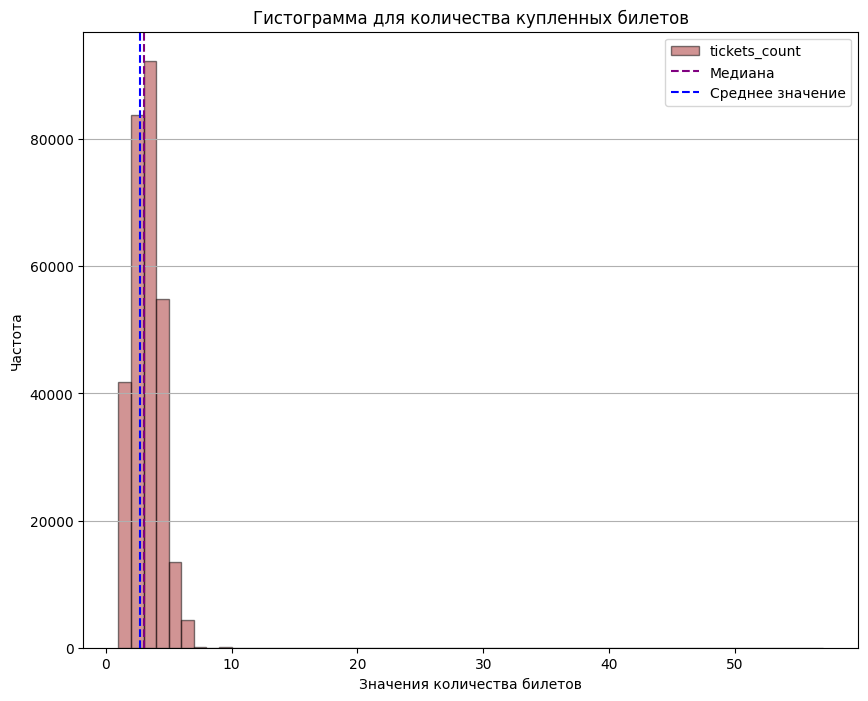

In [32]:
df['tickets_count'].plot(kind='hist', bins=range(min(df['tickets_count']), max(df['tickets_count']) + 1), figsize=(10, 8), color='brown', edgecolor='black', alpha=0.5).grid(axis='y')
plt.xlabel('Значения количества билетов')
plt.ylabel('Частота')
plt.title('Гистограмма для количества купленных билетов')
plt.axvline(df['tickets_count'].median(), linewidth=1.5, label='Медиана', color='purple', linestyle='--')
plt.axvline(df['tickets_count'].mean(), linewidth=1.5, label='Среднее значение', color='blue', linestyle='--')
plt.legend()

Судя по гистограмме, медиана и среднее значение примерно совпадают, что может являться признаком симметричного распределения. Однако в правой части гистограммы имеется хвост, значения которого трудно увидеть на гистограмме, так как их количество слишком мало по сравнению с основной массой данных. То есть распределение все-таки правоассиметричное и в данных есть выбросы.

Построим диаграмму размаха для того же столбца с отображением и без отображения выбросов.

Text(0.5, 0, 'Количество купленных билетов')

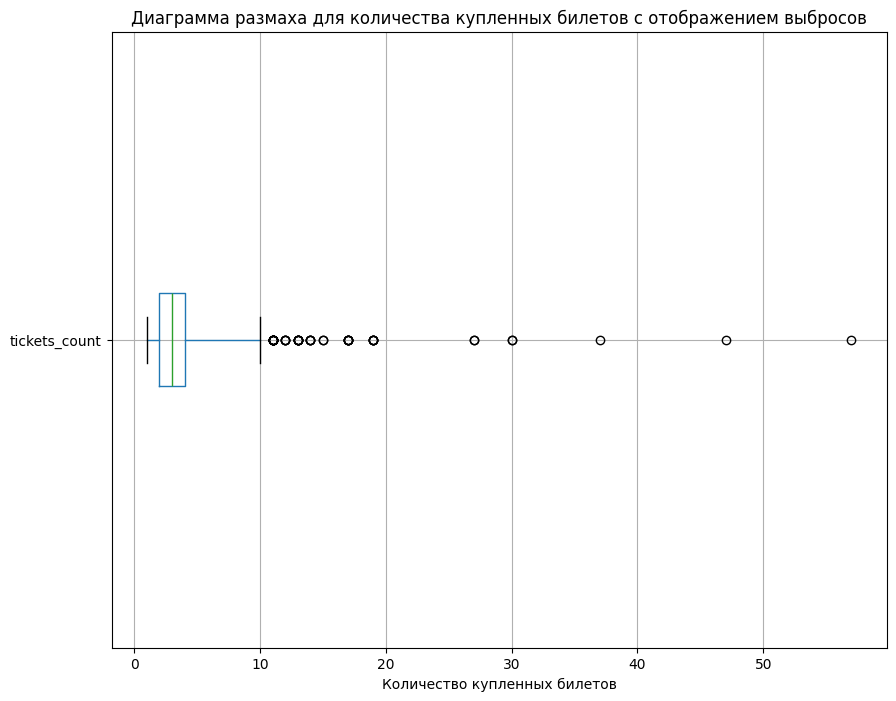

In [33]:
df.boxplot('tickets_count', vert=False, figsize=(10, 8), whis=3)
plt.title('Диаграмма размаха для количества купленных билетов с отображением выбросов')
plt.xlabel('Количество купленных билетов')

Text(0.5, 0, 'Количество купленных билетов')

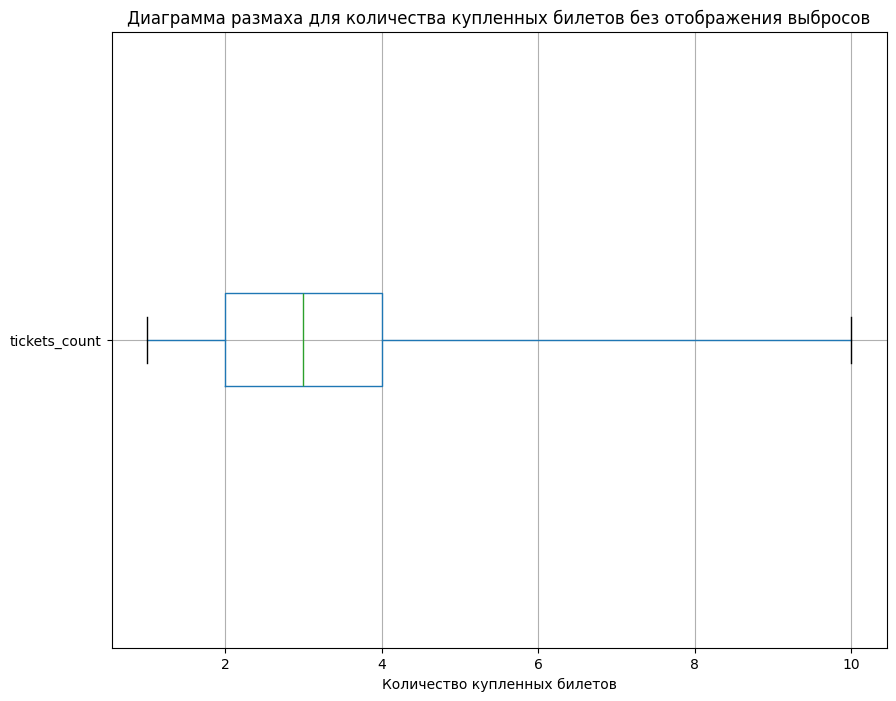

In [34]:
df.boxplot('tickets_count', vert=False, figsize=(10, 8), showfliers=False, whis=3)
plt.title('Диаграмма размаха для количества купленных билетов без отображения выбросов')
plt.xlabel('Количество купленных билетов')

Из диаграмм размаха видно, что медиана заключена ровно между 1 и 3 процентилями, то есть распределение данных между ними симметричное. Правый ус значительно длинее левого уса, что подтверждает правоассиметричное распределение данных. Вероятно, значения в пределах от 10 до 20 являются аномалиями, а значения больше 20 - выбросами. Чтобы не искажать будущие расчеты, удалим строки с аномалиями и выбросами.

In [35]:
df = df[df['tickets_count'] <= 10]
print(f'Было строк в исходном датасете: {start_shape}\nОсталось строк в датасете после обработки: {df.shape[0]}\nУдалено строк: {start_shape - df.shape[0]}\nПроцент потерь: {round((start_shape - df.shape[0])/start_shape*100, 2)}')

Было строк в исходном датасете: 290611
Осталось строк в датасете после обработки: 290563
Удалено строк: 48
Процент потерь: 0.02


Проанализируем распределение столбца `revenue_rub`.

In [36]:
df['revenue_rub'].describe()

count    290563.000000
mean        555.469015
std         875.336475
min         -90.760000
25%         113.970000
50%         351.060000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Избавимся от явных выбросов - так как выручка не может быть отрицательной, а минимальное значение меньше 0, отфильтруем только значения от 0 и более. 

In [37]:
df = df[df['revenue_rub'] >= 0]
print(df['revenue_rub'].describe(), '\n', df['revenue_rub'].mode())

count    290182.000000
mean        556.201601
std         875.677245
min           0.000000
25%         114.610000
50%         352.080000
75%         802.250000
max       81174.540000
Name: revenue_rub, dtype: float64 
 0    0.0
Name: revenue_rub, dtype: float64


Статистические значения выглядят допустимыми, вероятно, распределение является правоассиметричным, так как среднее значение довольно сильно сдвинуто вправо от медианы.

Построим гистограмму для столбца с выручкой в рублях.

Text(0, 0.5, 'Частота')

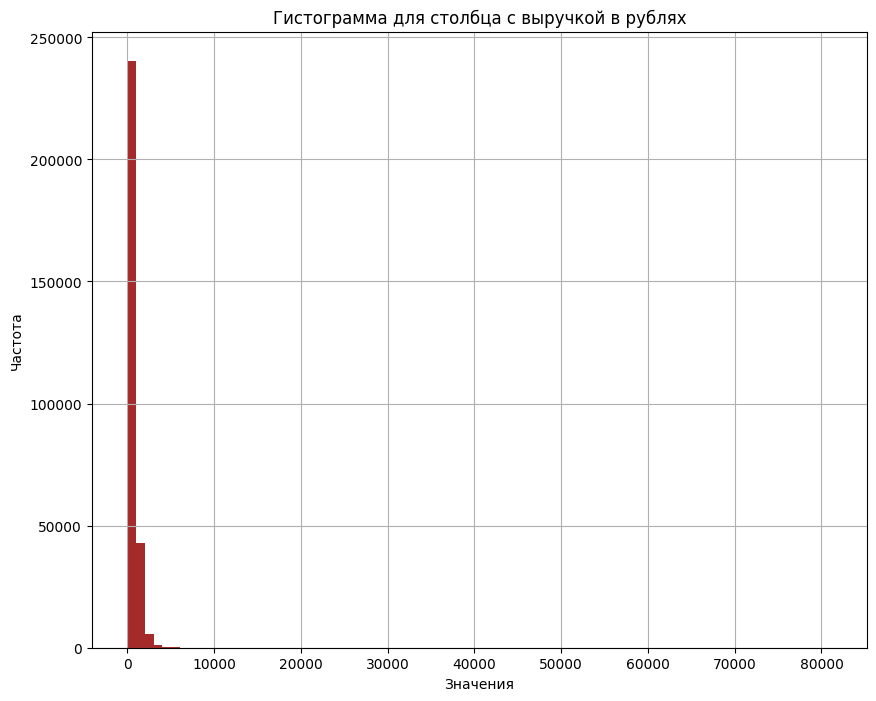

In [38]:
df['revenue_rub'].plot(kind='hist', bins=80, figsize=(10, 8), color='brown', grid=True, title='Гистограмма для столбца с выручкой в рублях')
plt.xlabel('Значения')
plt.ylabel('Частота')

Распределение правоассиметричное, вероятно, имеются выбросы при значениях больше примерно 5000, так как в той области выборочно встречаются большие значения, которые даже не отображаются на гистограмме за счет небольшого количества по сравнению с основной массой данных. Построим диаграмму размаха для проверки сделанного предположения.

Text(0.5, 0, 'Выручка в рублях')

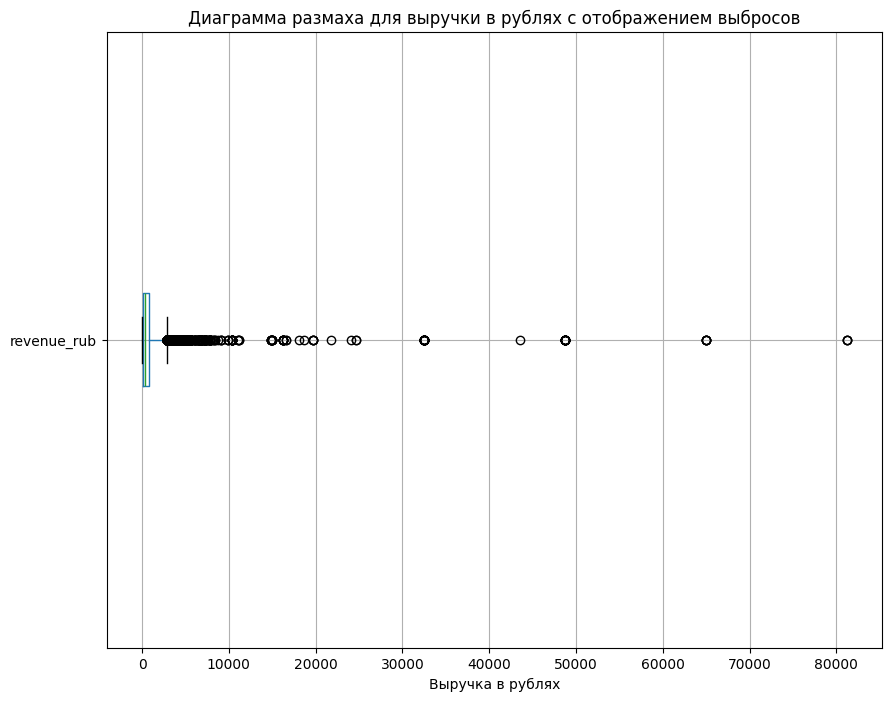

In [39]:
df.boxplot('revenue_rub', figsize=(10, 8), vert=False, whis=3)
plt.title('Диаграмма размаха для выручки в рублях с отображением выбросов')
plt.xlabel('Выручка в рублях')

Text(0.5, 0, 'Выручка в рублях')

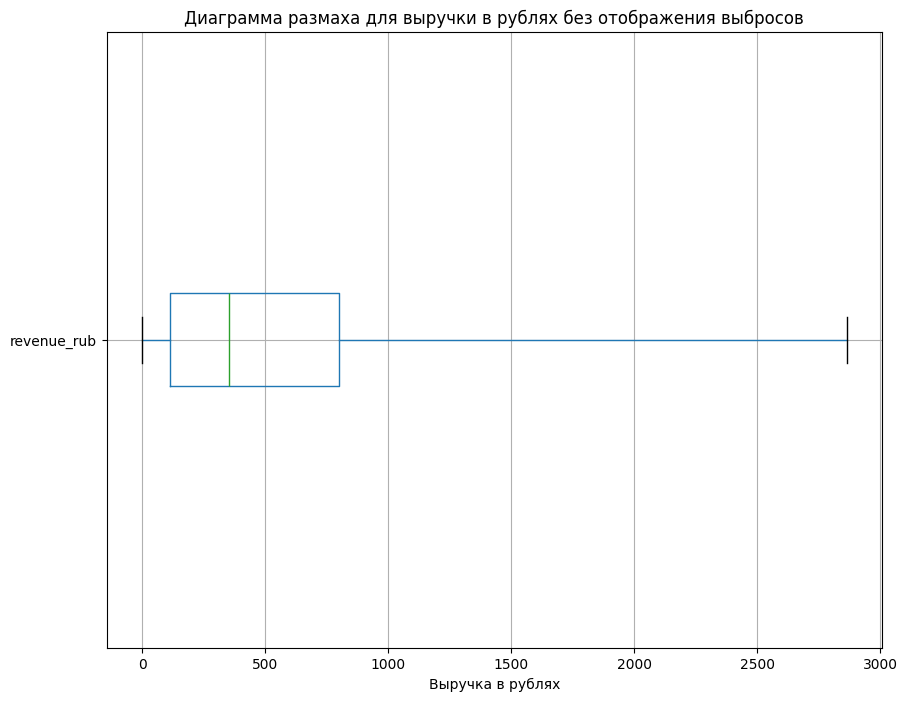

In [40]:
df.boxplot('revenue_rub', figsize=(10, 8), vert=False, whis=3, showfliers=False)
plt.title('Диаграмма размаха для выручки в рублях без отображения выбросов')
plt.xlabel('Выручка в рублях')

По диаграммам видно, что распределение действительно является правоассиметричным: правый хвост значительно больше левого, медиана сдвинута ближе к левому краю "коробки". В данных присутствуют выбросы. 

По условиям задания в случае обнаружения выбросов в поле `revenue_rub`, необходимо отфильтровать по 99 перцентилю.

In [41]:
# отфильтруем по 99 перцентилю
df = df[df['revenue_rub'] < df['revenue_rub'].quantile(0.99)]

In [42]:
print(f'Было строк в исходном датасете: {start_shape}\nОсталось строк в датасете после обработки: {df.shape[0]}\nУдалено строк: {start_shape - df.shape[0]}\nПроцент потерь: {round((start_shape - df.shape[0])/start_shape*100, 2)}')

Было строк в исходном датасете: 290611
Осталось строк в датасете после обработки: 287176
Удалено строк: 3435
Процент потерь: 1.18


#### Промежуточный вывод

В результате предобработки данных были выполнены следующие действия:
- создан столбец `revenue_rub` с выручкой в единой валюте - рублях;
- принято решение оставить пропуски в столбце `days_since_prev`;
- Сокращена размерность типов данных столбцов `order_id`, `revenue`, `tickets_count`, `days_since_prev`, `event_id`;
- Проверены и оставлены без изменений категориальные данные; 
- Очищены столбцы `revenue_rub`, `tickets_count` от выбросов.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3-bullet"></a>
### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---
<a class="anchor" id="3.1-bullet"></a>
**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Перед выполнением задания отсортируем данные по времени совершения заказа.

In [43]:
df = df.sort_values(by='order_ts')

Построим профиль пользователя.

In [44]:
user_profile = df.groupby('user_id').agg({'order_dt': ['first', 'last'], 
                                          'device_type_canonical': 'first', 
                                          'region_name': 'first', 
                                          'service_name': 'first',
                                          'event_type_main':'first',
                                          'user_id': 'count', 
                                          'revenue_rub': 'mean', 
                                          'tickets_count': 'mean', 
                                          'days_since_prev': 'mean'}).reset_index()
columns = ['user_id', 'first_order_dt', 'last_order_dt', 'device_first_order', 'region_first_order', 'service_name_first_order', 'first_event', 'total_orders', 'mean_revenue', 'mean_tickets_count', 'mean_days_since_prev']
user_profile.columns = columns
user_profile.head()

,user_id,first_order_dt,last_order_dt,device_first_order,region_first_order,service_name_first_order,first_event,total_orders,mean_revenue,mean_tickets_count,mean_days_since_prev
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0


Добавим 2 бинарных признака в профиль пользователя.

In [45]:
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5
user_profile.head()

,user_id,first_order_dt,last_order_dt,device_first_order,region_first_order,service_name_first_order,first_event,total_orders,mean_revenue,mean_tickets_count,mean_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.2-bullet"></a>
**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

Рассчитаем указанные в задании показатели.

In [46]:
print(f'''Общее число пользователей в выборке: {user_profile.shape[0]}
Средняя выручка с одного заказа: {round(user_profile['mean_revenue'].mean(), 2)} рублей
Доля пользователей, совершивших 2 и более заказа: {round(user_profile['is_two'].sum() / user_profile.shape[0] * 100, 2)}%
Доля пользователей, совершивших 5 и более заказов: {round(user_profile['is_five'].sum() / user_profile.shape[0] * 100, 2)}%''')

Общее число пользователей в выборке: 21831
Средняя выручка с одного заказа: 544.0 рублей
Доля пользователей, совершивших 2 и более заказа: 61.7%
Доля пользователей, совершивших 5 и более заказов: 29.0%


Соханим информацию о начальном размере датафрейма.

In [47]:
start_shape_profile = user_profile.shape[0]

Изучим статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

#### Изучение общего числа заказов

In [48]:
user_profile['total_orders'].describe()

count    21831.000000
mean        13.154505
std        121.487682
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10158.000000
Name: total_orders, dtype: float64

Максимальное количество заказов составляет 10158, что, вероятнее всего, является выбросом, то есть надо проверить данные на выбросы. Остальные показатели отображают вполне корректные значения. Среднее значение больше медианы примерно на 11, можно предположить, что распределение правоассиметричное.

Построим гистограмму, чтобы посмотреть на вид распределения.

Text(0, 0.5, 'Частота')

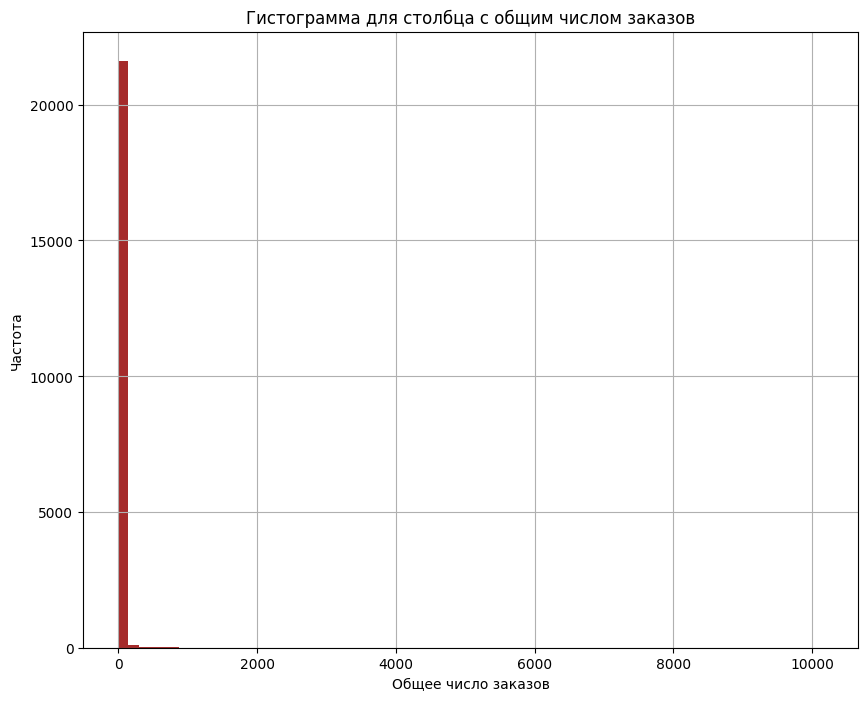

In [49]:
user_profile['total_orders'].plot(kind='hist', color='brown', grid=True, bins=70, figsize=(10, 8), title='Гистограмма для столбца с общим числом заказов')
plt.xlabel('Общее число заказов')
plt.ylabel('Частота')

Судя по гистограмме, распределение является правоассиметричным, наибольшее количество людей не совершили и 500 заказов, значения, большие 500 с большой вероятностью могут быть идентифицированы как выбросы. 

Построим диаграмму размаха, чтобы понять, как правильнее поступить с выбросами.

Text(0.5, 0, 'Общее число заказов')

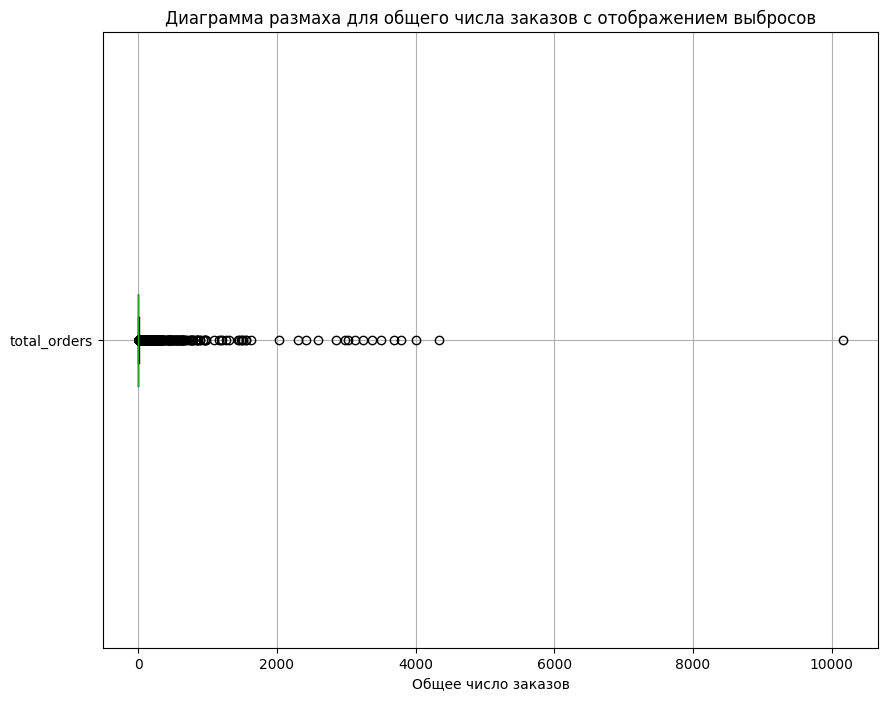

In [50]:
user_profile.boxplot('total_orders', vert=False, figsize=(10, 8), whis=3)
plt.title('Диаграмма размаха для общего числа заказов с отображением выбросов')
plt.xlabel('Общее число заказов')

Text(0.5, 0, 'Общее число заказов')

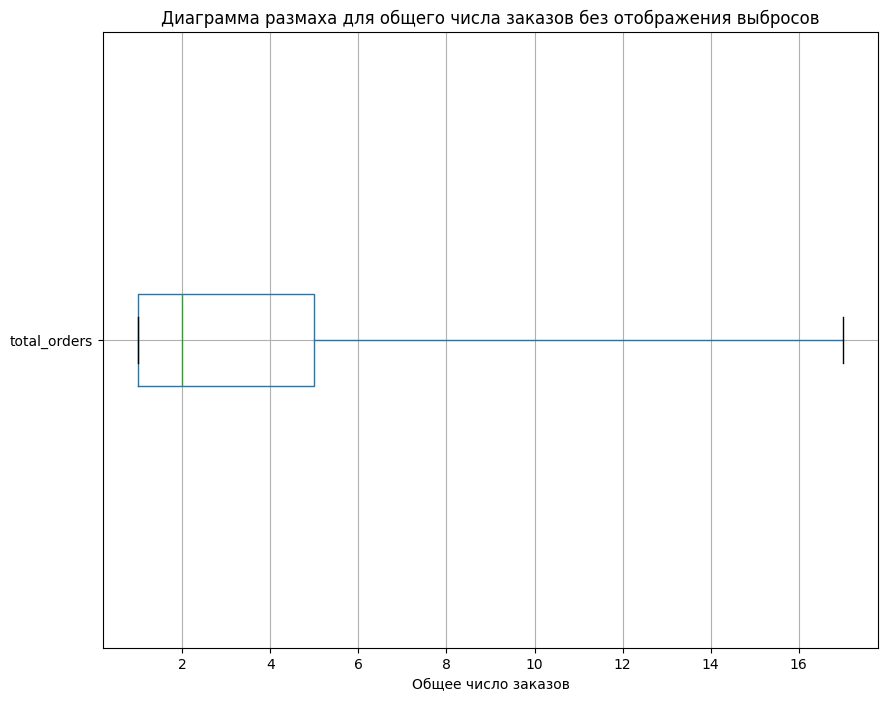

In [51]:
user_profile.boxplot('total_orders', vert=False, figsize=(10, 8), showfliers=False, whis=3)
plt.title('Диаграмма размаха для общего числа заказов без отображения выбросов')
plt.xlabel('Общее число заказов')

Судя по диаграмме размаха, все значения, большие 17, являются выбросами. Однако в таком случае получается неоправданно большое количество выбросов - количество заказов вполне возможно и более 17.

Предположим, что можно отфильтровать данные по 99-му перцентилю. Проверим чему равно это значение.

In [52]:
user_profile['total_orders'].quantile(0.99)

np.float64(152.0)

Значение 99 перцентиля равно 152. Чтобы понять, что делать с выбросами, обратимся к цели исследования: определить типичный образ пользователя, который возвращается на платформу и делает заказы повторно. Если оставить пользователей с бОльшим количеством покупок, чем в 99 перцентиле, то будет составлен уже не типичный образ покупателя, а рассмотрены аномальные случаи либо даже выбросы. Так как исследование не предполагает изучение краевых случаев, стоит отфильтровать данные по 99 перцентилю, они дадут более корректное представление о типичном пользователе.

In [53]:
# фильтрация по 99 перцентилю
user_profile = user_profile[user_profile['total_orders'] < user_profile['total_orders'].quantile(0.99)]

#### Изучение среднего числа билетов в заказе

In [54]:
user_profile['mean_tickets_count'].describe()

count    21611.000000
mean         2.742790
std          0.913608
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         10.000000
Name: mean_tickets_count, dtype: float64

Статистические показатели по среднему количеству билетов в заказе выглядят правдоподобно. Нет отрицательных значений, наибольшее значение равно 10, что является допустимым. Среднее значение (примерно 2.74) и медиана (2.75) находятся близо друг к другу, значит есть основания предполагать, что распределение может быть симметричным. Можно сделать предположение, которое проверим ниже, что выбросов в данных нет.

Построим гистограмму для столбца со средним числом билетов в заказе, определим вид распределения.

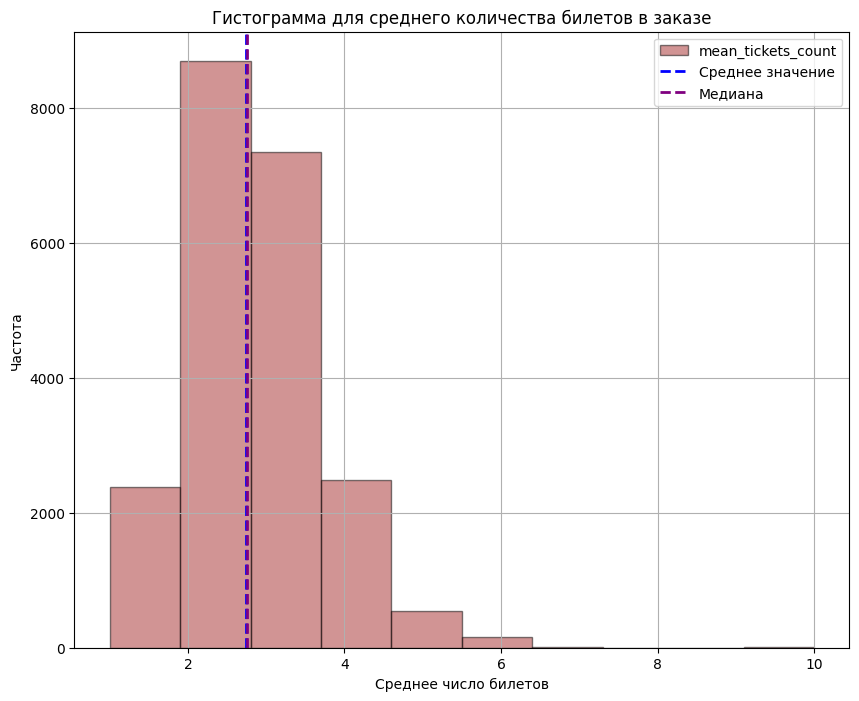

In [55]:
user_profile['mean_tickets_count'].plot(kind='hist', color='brown', alpha=0.5, figsize=(10, 8), edgecolor='black', grid=True, title='Гистограмма для среднего количества билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.ylabel('Частота')
plt.axvline(user_profile['mean_tickets_count'].mean(), label='Среднее значение', linewidth=2, color='blue', linestyle='--')
plt.axvline(user_profile['mean_tickets_count'].median(), label='Медиана', linewidth=2, color='purple', linestyle='--')
plt.legend()

Распределение имеет небольшой скос справа, после значения 6 имеется разрыв и на гистограмме уже не видно явных значений, количество которых было бы большое, вплоть до 10. Вероятно, это происходит из-за наличия аномально больших значений либо выбросов. Оценим аномальные значения по диаграмме размаха.

Text(0.5, 0, 'Среднее число билетов в заказе')

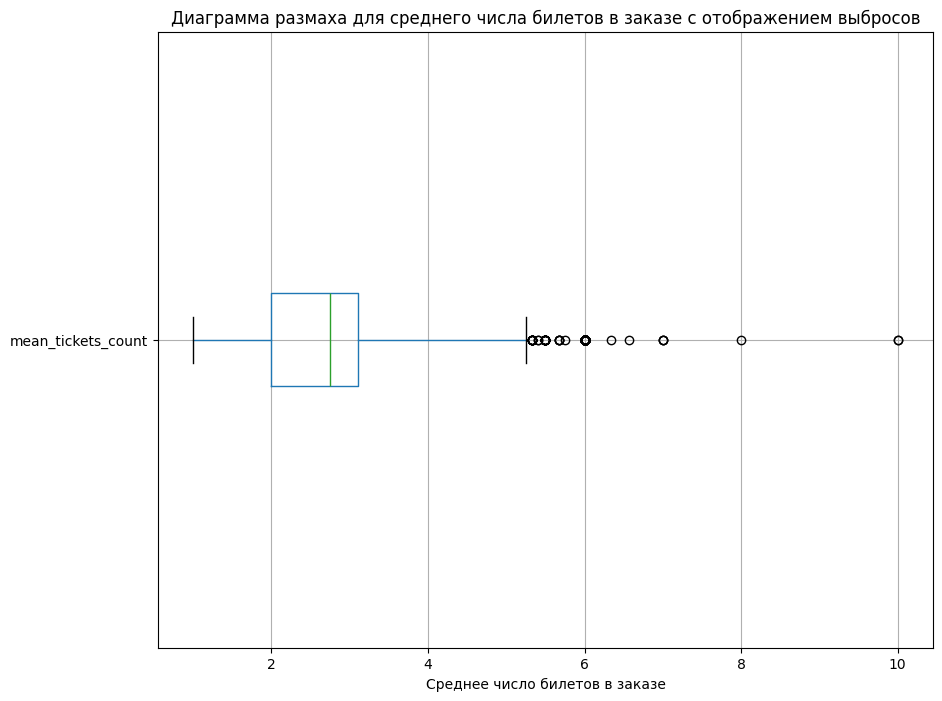

In [56]:
user_profile.boxplot('mean_tickets_count', vert=False, whis=2, figsize=(10, 8))
plt.title('Диаграмма размаха для среднего числа билетов в заказе с отображением выбросов')
plt.xlabel('Среднее число билетов в заказе')

Действительно, по диаграмме размаха видно, что значения в пределах 5 и более могут считаться выбросами. Опять же, для составления профиля типичного пользователя не будем брать в учет нестандартные случаи. Отфильтруем такие значения.

Проверим значение 99-го перцентиля.

In [57]:
user_profile['mean_tickets_count'].quantile(0.99)

np.float64(5.0)

99-ый перцентиль как раз принимает значение 5. Отфильтруем по нему.

In [58]:
user_profile = user_profile[user_profile['mean_tickets_count'] < user_profile['mean_tickets_count'].quantile(0.99)]

#### Изучение среднего количества дней между покупками

In [59]:
user_profile['mean_days_since_prev'].describe()

count    13157.000000
mean        16.207548
std         22.441355
min          0.000000
25%          1.480000
50%          8.500000
75%         21.000000
max        148.000000
Name: mean_days_since_prev, dtype: float64

Значения среднего количества дней между покупками выглядят правдоподобно: нет отрицательных значений, максимальное значение, равное 148, допустимо для людей, которые делают заказы редко. Среднее значение больше медианы примерно в 2 раза. Можно сделать предположение, то распределение является правоассиметричным. 

Построим гистограмму, определим вид распределения.

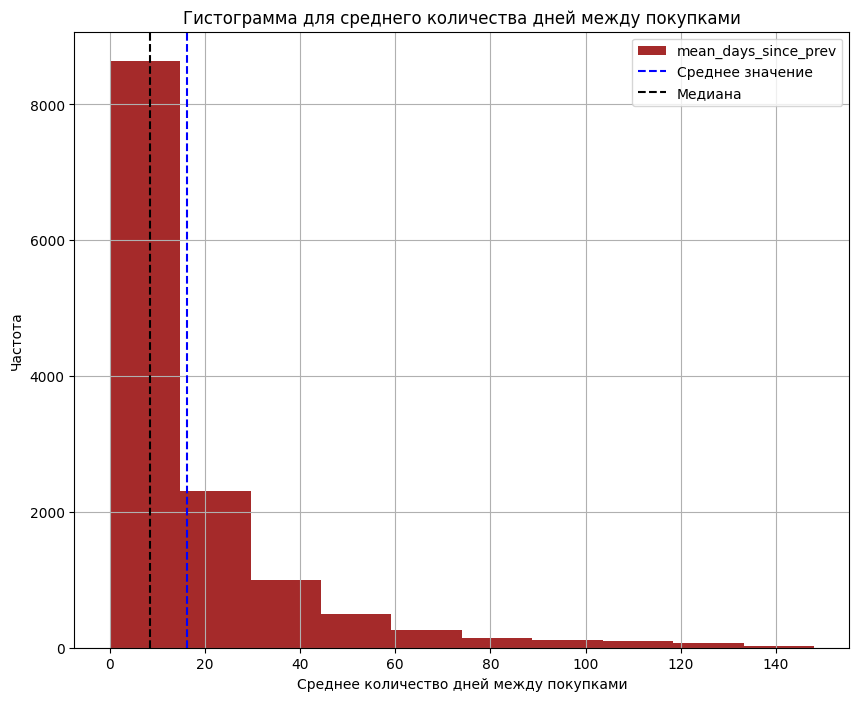

In [60]:
user_profile['mean_days_since_prev'].plot(kind='hist', figsize=(10, 8), color='brown', grid=True, title='Гистограмма для среднего количества дней между покупками')
plt.xlabel('Среднее количество дней между покупками')
plt.ylabel('Частота')
plt.axvline(user_profile['mean_days_since_prev'].mean(), color='blue', linewidth=1.5, linestyle='--', label='Среднее значение')
plt.axvline(user_profile['mean_days_since_prev'].median(), color='black', linewidth=1.5, linestyle='--', label='Медиана')
plt.legend()

Распределение является правоассиметричным, среднее значение сдвинуто правее медианы. На гистограмме не видно разрывов, прослеживается логичная тенденция, где большое количество дней между покупками (60 и более) встречается реже, чем количество дней до 60.

Явно видные столбцы гистограммы доходят до значения 140, после чего график заканчивается. Вероятно, выбросов в этом столбце нет.

Построит диаграмму размаха с отображением выбросов для столбца со средним количеством покупок.

Text(0.5, 0, 'Среднее количество дней между покупками')

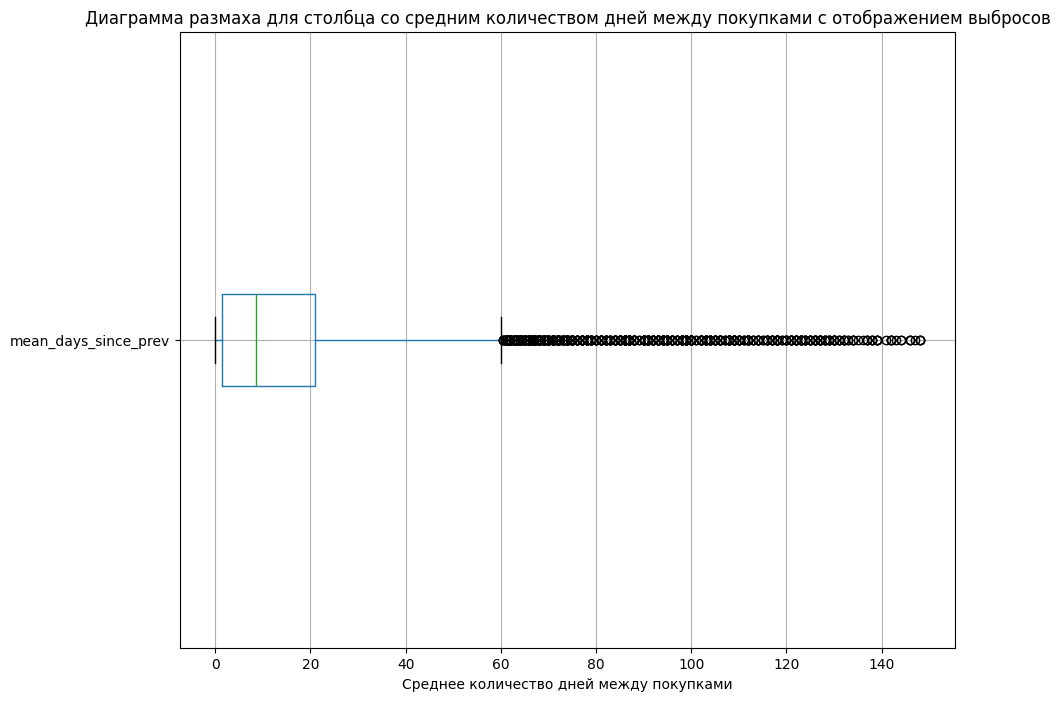

In [61]:
user_profile.boxplot('mean_days_since_prev', vert=False, whis=2, figsize=(10, 8))
plt.title('Диаграмма размаха для столбца со средним количеством дней между покупками с отображением выбросов')
plt.xlabel('Среднее количество дней между покупками')

На диаграмме размаха все значения, от 60 до 148, помечены как выбросы, однако количество таких отметок очень большое, не прослеживается тенденция аномальных отклонений либо выбросов. Значит данные со средним количеством дней между покупками фильтровать необходимости нет.

Проведем анализ отфильтрованного объема данных, выведем информацию об обновленном датафрейме.

In [62]:
print(f'Было строк в исходном датасете: {start_shape_profile}\nОсталось строк в датасете после обработки: {user_profile.shape[0]}\nУдалено строк: {start_shape_profile - user_profile.shape[0]}\nПроцент потерь: {round((start_shape_profile - user_profile.shape[0])/start_shape_profile*100, 2)}')

Было строк в исходном датасете: 21831
Осталось строк в датасете после обработки: 20954
Удалено строк: 877
Процент потерь: 4.02


In [63]:
print(f'''Общее число пользователей в выборке: {user_profile.shape[0]}
Средняя выручка с одного заказа: {round(user_profile['mean_revenue'].mean(), 2)} рублей
Доля пользователей, совершивших 2 и более заказа: {round(user_profile['is_two'].sum() / user_profile.shape[0] * 100, 2)}%
Доля пользователей, совершивших 5 и более заказов: {round(user_profile['is_five'].sum() / user_profile.shape[0] * 100, 2)}%''')

Общее число пользователей в выборке: 20954
Средняя выручка с одного заказа: 535.05 рублей
Доля пользователей, совершивших 2 и более заказа: 62.66%
Доля пользователей, совершивших 5 и более заказов: 29.1%


В процессе обработки данных были отфильтрованы столбцы `total_orders`, `mean_tickets_count`, был удален примерно 4% данных, осталось 20954 строк. Достаточно ли такого объема данных для анализа зависит от общего числа пользователей сервиса, но вероятно, в контексте задачи выявления тенденции поведения, примерно 21000 пользователей - действительно достаточное количество. 

Средняя выручка с покупки пользователя составляет 535 рублей, примерно 63% пользователей совершают 2 и более заказа, 29% - 5 и более заказов. Как итог - примерно 37% пользователей решают не пользоваться сервисом повторно против 63%, кто возвращается на платформу.

#### Промежуточный вывод

На третьем шаге был создан профиль пользователя, включающий в себя: 
- дату первого и последнего заказа - `first_order_dt`, `last_order_dt`;
- устройство, с которого был сделан первый заказ - `device_first_order`;
- регион, в котором был сделан первый заказ - `region_first_order`;
- билетного партнёра, к которому обращались при первом заказе - `service_name_first_order`;
- жанр первого посещённого мероприятия - `first_event`;
- общее количество заказов - `total_orders`;
- среднюю выручку с одного заказа в рублях - `mean_revenue`;
- среднее количество билетов в заказе - `mean_tickets_count`;
- среднее время между заказами - `mean_days_since_prev`;
- индикатор, совершил ли пользователь 2 и более заказа - `is_two`;
- индикатор, совершил ли пользователь 5 и более заказов - `is_five`.

В процессе обработки данных общее число заказов `total_orders`, а также среднее число билетов в заказе `mean_tickets_count` были отфильтрованы по 99-му перцентилю. Среднее количество дней между покупками `mean_days_since_prev` отфильтровано не было.

В результате обработки показатели по обновлённому датасету следующие:
- удалено примерно 4% данных; 
- осталось 20954 строк;
- средняя выручка с покупки пользователя составляет 535 рублей;
- примерно 63% пользователей совершают 2 и более заказа;
- примерно 29% пользователей совершают 5 и более заказов.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="4-bullet"></a>
### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.


<a class="anchor" id="4.1-bullet"></a>
#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---
<a class="anchor" id="4.1.1-bullet"></a>
**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


В данном задании вместо группировки можно использовать функцию `value_counts` и ее параметр - normalize, так как каждая строка представляет одного пользователя.

Например, вместо группировки, представленной ниже, просто применить функцию и найти сразу абсолютные и относительные значения.

In [64]:
# использование группировки

grouped_first_event = user_profile.groupby(by='first_event')['user_id'].count().sort_values(ascending=False)
grouped_first_event_rel = user_profile.groupby(by='first_event')['user_id'].count().sort_values(ascending=False) / user_profile.shape[0]
result_event = pd.concat([grouped_first_event, grouped_first_event_rel], axis=1)
result_event.columns = ['Абсолютное количество', 'Относительное количество']
result_event.index.name = 'Тип первого мероприятия'
result_event

,Абсолютное количество,Относительное количество
Тип первого мероприятия,,
концерты,9366,0.446979
другое,5170,0.246731
театр,4109,0.196096
стендап,1073,0.051207
спорт,740,0.035315
выставки,406,0.019376
ёлки,90,0.004295


In [65]:
# использование функции

event_abs = user_profile['first_event'].value_counts()
event_rel = user_profile['first_event'].value_counts(normalize=True)
result_event = pd.concat([event_abs, event_rel], axis=1)
result_event.columns = ['Абсолютное количество', 'Относительное количество']
result_event.index.name = 'Тип первого мероприятия'
result_event

,Абсолютное количество,Относительное количество
Тип первого мероприятия,,
концерты,9366,0.446979
другое,5170,0.246731
театр,4109,0.196096
стендап,1073,0.051207
спорт,740,0.035315
выставки,406,0.019376
ёлки,90,0.004295


Напишем функцию, которая будет группировать пользователей и выдавать единый датафрейм с абсолютными и относительными значениями. 

In [66]:
def create_abs_rel(name_column, name_index):
    event_abs = user_profile[name_column].value_counts()
    event_rel = user_profile[name_column].value_counts(normalize=True)
    result_event = pd.concat([event_abs, event_rel], axis=1)
    result_event.columns = ['Абсолютное количество', 'Относительное количество']
    result_event.index.name = name_index
    return result_event

Будем использовать для подсчета функцию.

Изучение распределения пользователей по типу их первого мероприятия.

In [67]:
create_abs_rel('first_event', 'Тип первого мероприятия')

,Абсолютное количество,Относительное количество
Тип первого мероприятия,,
концерты,9366,0.446979
другое,5170,0.246731
театр,4109,0.196096
стендап,1073,0.051207
спорт,740,0.035315
выставки,406,0.019376
ёлки,90,0.004295


Пользователи распределены неравномерно в зависимости от первого мероприятия, на которое приобрели билет. Наименьшее количество первых покупок приходится на елки. Предположительно, это происходит из-за того, что это сезонное мероприятие, билеты на которое актуальны только в первой половине зимы. Наиболее популярными категориями являются концерты, театры, а также категория "другое".

---

Изучение распределения пользователей по типу устройства, с которого совершена первая покупка.

In [68]:
create_abs_rel('device_first_order', 'Тип устройства первой покупки')

,Абсолютное количество,Относительное количество
Тип устройства первой покупки,,
mobile,17372,0.829054
desktop,3582,0.170946


Большое преимущество забирают заказы, сделанные с телефонного устройства, количество которых почти в 5 раз превышает заказы, сделанные с компьютера. Вероятно, в таком случае стоит обратить внимание на мобильную версию сайта, чтобы сделать ее более интуитивно понятной и визуально привлекательной для пользователей.

---

Изучение распределения пользователей по региону проведения мероприятия из первого заказа.

In [69]:
create_abs_rel('region_first_order', 'Регион мероприятия первого заказа')

,Абсолютное количество,Относительное количество
Регион мероприятия первого заказа,,
Каменевский регион,6877,0.328195
Североярская область,3626,0.173046
Широковская область,1174,0.056027
Озернинский край,651,0.031068
Малиновоярский округ,515,0.024578
...,...,...
Светолесский край,2,0.000095
Тихогорская область,2,0.000095
Сосноводолинская область,1,0.000048


Пользователи распределены крайне неравномерно по регионам проведения мероприятия из первого заказа. Так, наибольшее количество заказов присуще каменевскому региону, североярской области и широковской области (около 33%, 17% и 6% соответственно). Наименьшее - сосноводолинской области, яснопольскому округу и верхозёрскому краю (по 1 заказу - 0,005%).

---

Изучение распределения пользователей по билетному оператору, продавшему билеты на первый раз.

In [70]:
create_abs_rel('service_name_first_order', 'Билетный оператор первого заказа')

,Абсолютное количество,Относительное количество
Билетный оператор первого заказа,,
Билеты без проблем,5002,0.238713
Мой билет,2869,0.136919
Лови билет!,2724,0.129999
Билеты в руки,2480,0.118354
Облачко,2146,0.102415
Весь в билетах,1251,0.059702
Лучшие билеты,1135,0.054166
Прачечная,562,0.026821
Край билетов,440,0.020998


Пользователи так же неравномерно распределены по билетным операторам, продавшем билеты на первый заказ. Наибольшее количество пользователей отдали предпочтение операторам "Билеты без проблем", "Мой билет", "Лови билет!" (около 24%, 14%, 13% соот-но), наименьшее - операторам "Лимоны", "Тех билет", "Зе Бест!" (по 0,01%; 0,01%; 0,005% соот-но). Возможно, это говорит о более профессиональной работе одних операторов и менее профессиональной других.

---

Таким образом, в каждом признаке есть своя "точка входа" - сегменты с наибольшим числом пользователей. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Напишем функцию, которая будет находить долю повторно вернувшихся пользователей в каждом сегменте для каждого признака.

In [71]:
def func_is_two(column_name):
    more_2 = user_profile.groupby(by=[column_name])['is_two'].agg(['sum', 'count']) 
    more_2['Доля вернувшихся пользователей'] = more_2['sum'] / more_2['count']
    more_2 = more_2.sort_values(by='Доля вернувшихся пользователей')
    more_2['Доля вернувшихся пользователей']
    
    return more_2

---

Вычислим для каждого сегмента признака "тип первого мероприятия" долю пользователей, совершивших два и более заказа.

In [72]:
event_2_more = func_is_two('first_event')
event_2_more['Доля вернувшихся пользователей']

first_event
спорт       0.582432
ёлки        0.588889
другое      0.614894
стендап     0.625349
концерты    0.625988
выставки    0.647783
театр       0.649793
Name: Доля вернувшихся пользователей, dtype: float64

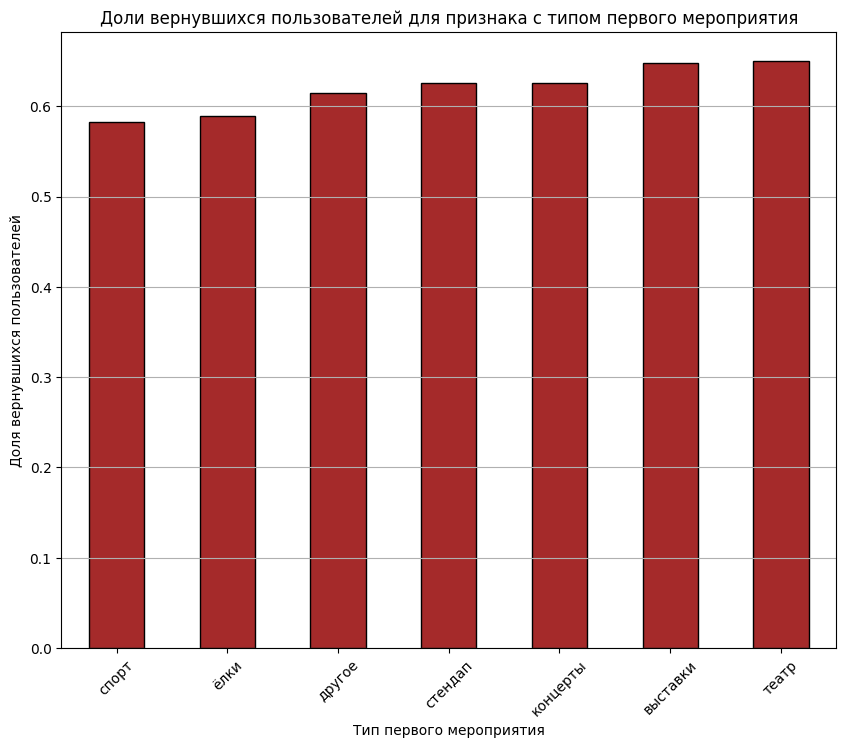

In [73]:
event_2_more.plot(kind='bar', y='Доля вернувшихся пользователей', color='brown', edgecolor='black', figsize=(10, 8), rot=45, xlabel='Тип первого мероприятия', ylabel='Доля вернувшихся пользователей', title='Доли вернувшихся пользователей для признака с типом первого мероприятия', legend=False).grid(axis='y')

Из столбчатой диаграммы видно, что наибольший процент возврата присущ людям, покупающим первый билет в театр, - около 65%. Наименьший процент возврата присущ людям, покупающим билеты на спорт - около 58%. В целом данные сегменты могут оказать небольшое влияние на то, вернется ли человек за покупкой билета.

---

Вычислим для каждого сегмента признака "тип устройства, с которого совершена первая покупка" долю пользователей, совершивших два и более заказа.

In [74]:
device_2_more = func_is_two('device_first_order')
device_2_more['Доля вернувшихся пользователей']

device_first_order
mobile     0.620827
desktop    0.654662
Name: Доля вернувшихся пользователей, dtype: float64

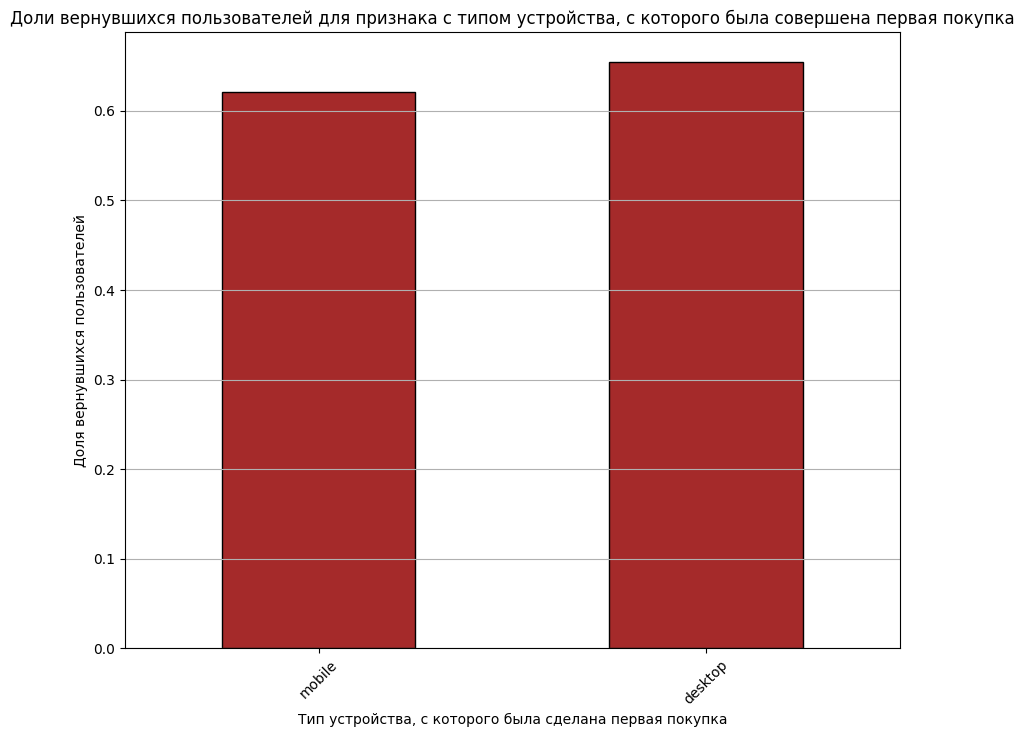

In [75]:
device_2_more.plot(kind='bar', y='Доля вернувшихся пользователей', color='brown', edgecolor='black', figsize=(10, 8), rot=45, xlabel='Тип устройства, с которого была сделана первая покупка', ylabel='Доля вернувшихся пользователей', title='Доли вернувшихся пользователей для признака с типом устройства, с которого была совершена первая покупка', legend=False).grid(axis='y')

Тип устройства не оказывает сильного влияния на то, вернется ли пользователь за покупкой. Возвраты после первого заказа с компьютера лишь на 3% превышают мобильную версию.

---

Вычислим для каждого сегмента признака "регион проведения мероприятия из первого заказа" долю пользователей, совершивших два и более заказа.

In [76]:
# выведем 10 сегментов с наибольшим количеством пользователей
region_2_more = func_is_two('region_first_order').sort_values(by='count')[-10:].sort_values(by='Доля вернувшихся пользователей')
region_2_more['Доля вернувшихся пользователей']

region_first_order
Малиновоярский округ    0.563107
Озернинский край        0.566820
Яблоневская область     0.611529
Травяная область        0.623431
Каменевский регион      0.638069
Речиновская область     0.644028
Североярская область    0.654440
Широковская область     0.660136
Светополянский округ    0.670404
Шанырский регион        0.676000
Name: Доля вернувшихся пользователей, dtype: float64

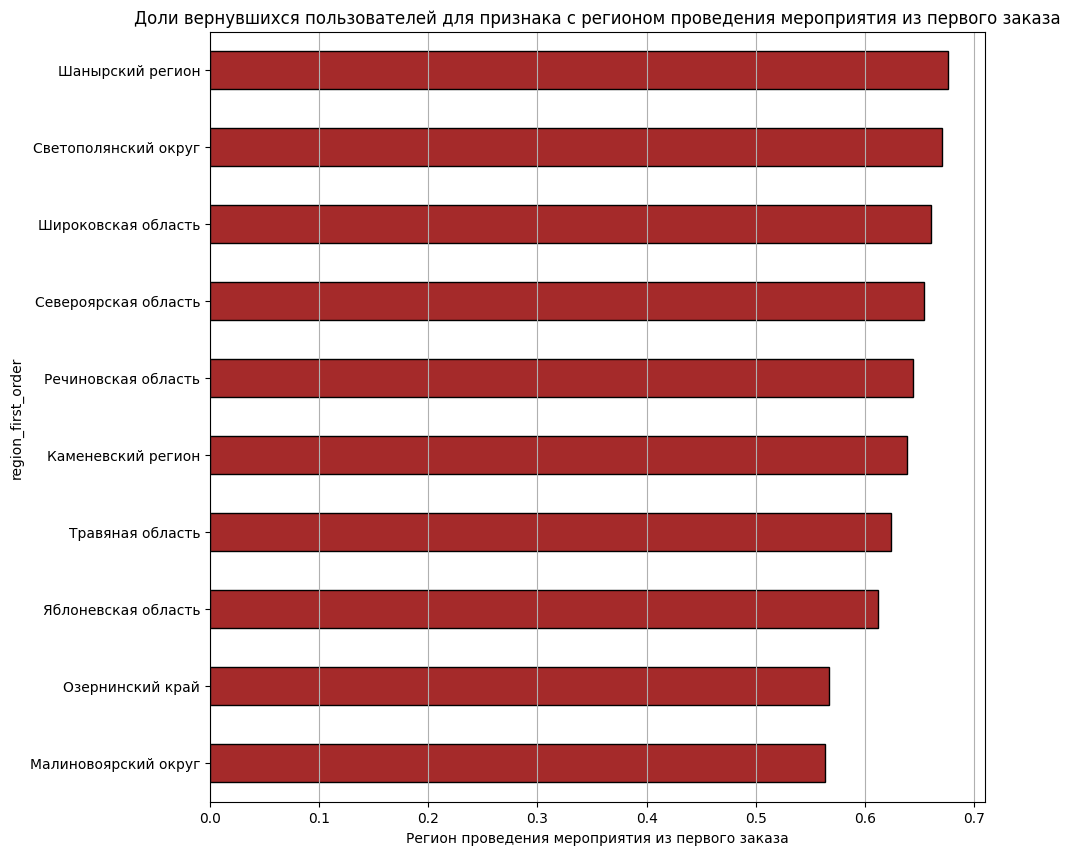

In [77]:
region_2_more.plot(kind='barh', y='Доля вернувшихся пользователей', legend=False, color='brown', edgecolor='black', figsize=(10, 10), xlabel='Регион проведения мероприятия из первого заказа', title='Доли вернувшихся пользователей для признака с регионом проведения мероприятия из первого заказа').grid(axis='x')

Построим диаграмму, чтобы наглядно увидеть количество пользователей, купивших первый раз билеты на мероприятия в данных регионах.

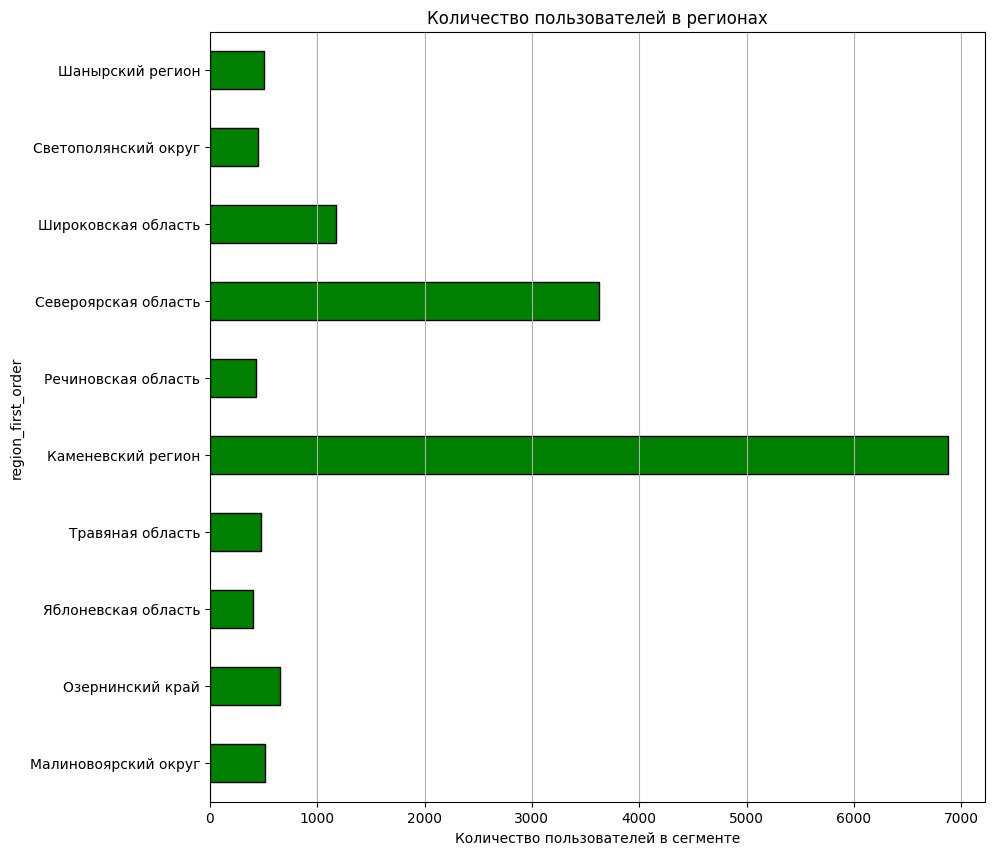

In [78]:
region_2_more.plot(kind='barh', y='count', color='green', edgecolor='black', figsize=(10, 10), xlabel='Количество пользователей в сегменте', legend=False, title='Количество пользователей в регионах').grid(axis='x')

Из диаграмм можно увидеть, что нет четкой зависимости между количеством пользователей в сегменте и долей вернувшихся за новыми покупками пользователей. Так, каменевский регион с наибольшим количеством человек имеет примерно 64 процента возвратов, в то время как шанырский регион, количество человек в котором меньше более чем в 10 раз по сравнению с каменевским регионом - наибольший процент возвратов - около 68. 

Однако трудно оценивать достоверную корреляцию между количеством людей и возвратами из-за очень сильно варьирующихся значений количества пользователей. Посмотрим на примере.

In [79]:
# выведем 10 сегментов с наименьшим количеством пользователей
region_2_more_2 = func_is_two('region_first_order').sort_values(by='count')[:10].sort_values(by='Доля вернувшихся пользователей')
region_2_more_2['Доля вернувшихся пользователей']

region_first_order
Яснопольский округ          0.000000
Сосноводолинская область    0.000000
Островогорский округ        0.333333
Теплоозёрский округ         0.333333
Залесский край              0.500000
Светолесский край           0.500000
Тихогорская область         0.500000
Верховинская область        0.666667
Лесноярский край            0.666667
Верхозёрский край           1.000000
Name: Доля вернувшихся пользователей, dtype: float64

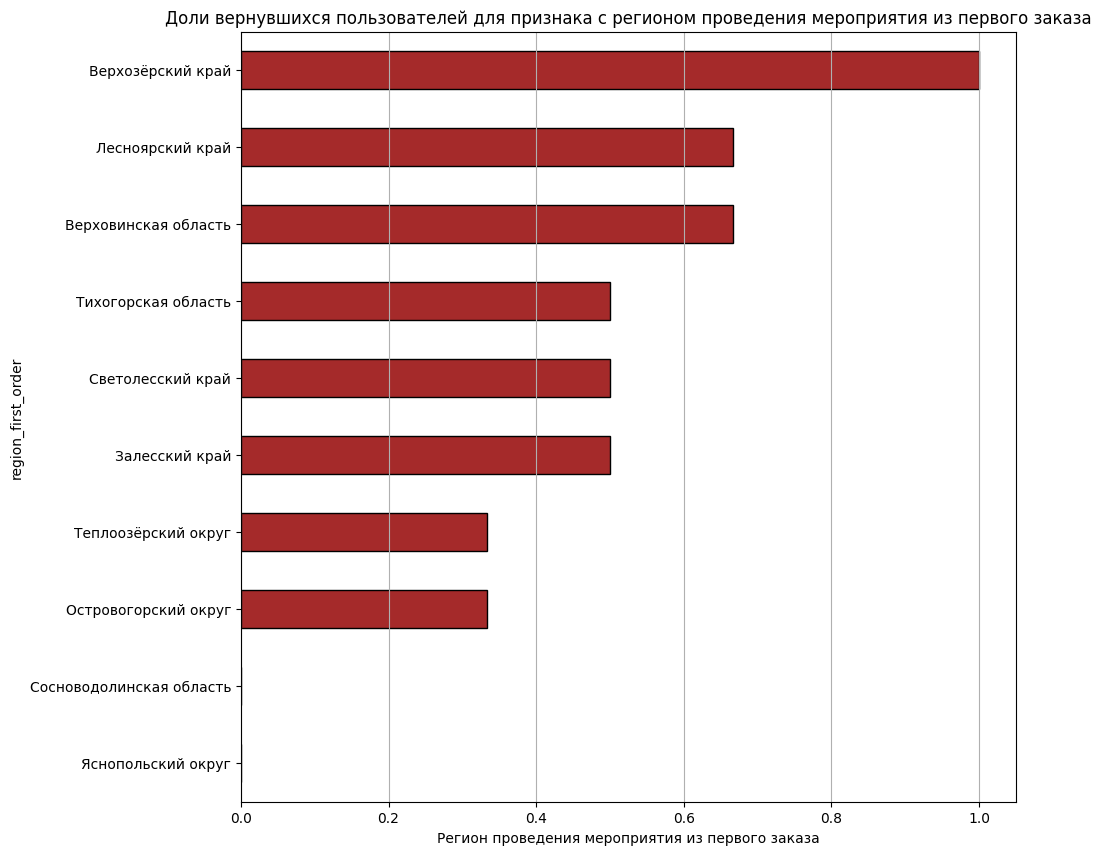

In [80]:
region_2_more_2.plot(kind='barh', y='Доля вернувшихся пользователей', legend=False, color='brown', edgecolor='black', figsize=(10, 10), xlabel='Регион проведения мероприятия из первого заказа', title='Доли вернувшихся пользователей для признака с регионом проведения мероприятия из первого заказа').grid(axis='x')

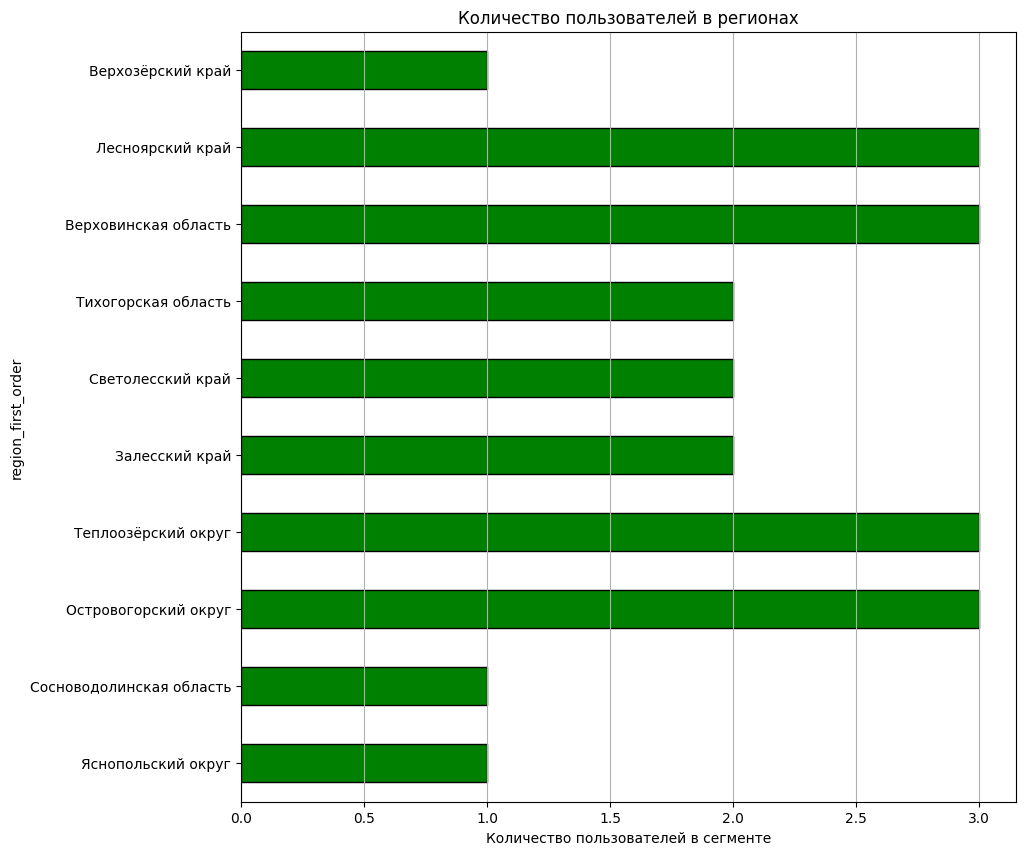

In [81]:
region_2_more_2.plot(kind='barh', y='count', color='green', edgecolor='black', figsize=(10, 10), xlabel='Количество пользователей в сегменте', legend=False, title='Количество пользователей в регионах').grid(axis='x')

Можно увидеть, что наибольший процент возвратов (100%) присущ верхозёрскому краю, в котором всего 1 пользователь; в сосноводолинской области и яснопольском округе 0% возвратов, однако там так же всего 1 пользователь. То есть статистика зависит всего от действий 1 пользователя, что не дает в полной мере корректно интерпретировать результаты.

---

Вычислим для каждого сегмента признака "билетный оператор, продавший билеты на первый заказ" долю пользователей, совершивших два и более заказа.

In [82]:
service_name_2_more = func_is_two('service_name_first_order').sort_values(by='count')[-10:].sort_values(by='Доля вернувшихся пользователей')
service_name_2_more['Доля вернувшихся пользователей']

service_name_first_order
Билеты без проблем    0.616953
Облачко               0.617428
Мой билет             0.621471
Лови билет!           0.624816
Лучшие билеты         0.633480
Билеты в руки         0.639919
Весь в билетах        0.640288
Прачечная             0.644128
Край билетов          0.665909
Дом культуры          0.672515
Name: Доля вернувшихся пользователей, dtype: float64

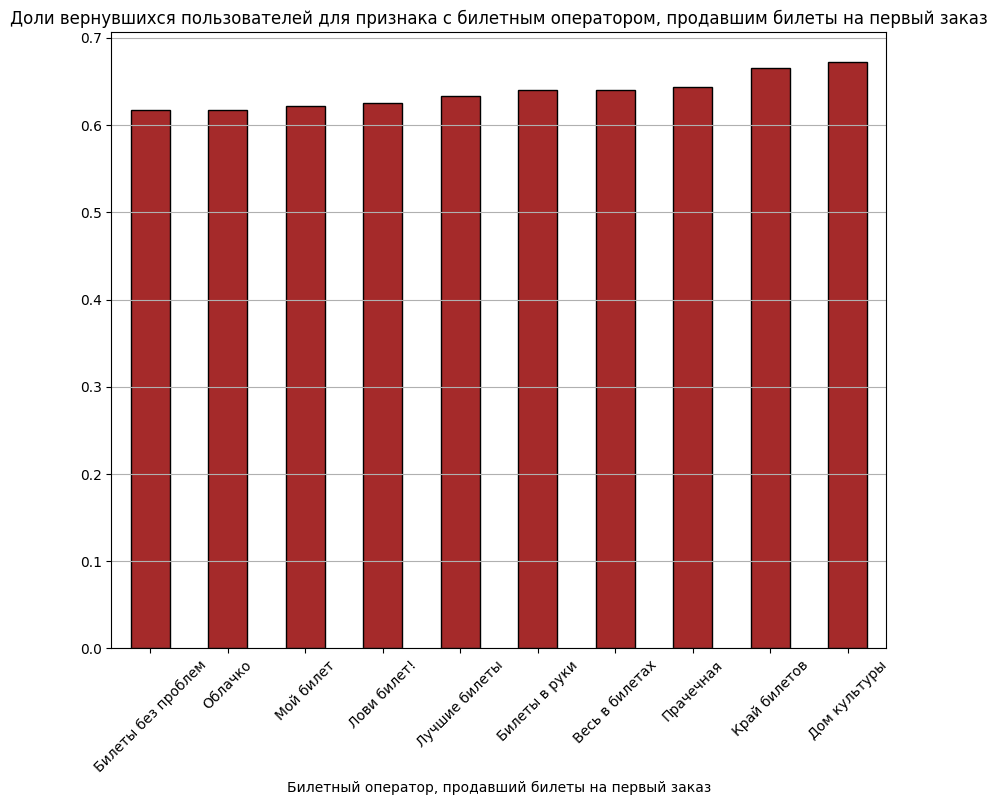

In [83]:
service_name_2_more.plot(kind='bar', rot=45, legend=False, y='Доля вернувшихся пользователей', color='brown', edgecolor='black', figsize=(10, 8), xlabel='Билетный оператор, продавший билеты на первый заказ', title='Доли вернувшихся пользователей для признака с билетным оператором, продавшим билеты на первый заказ').grid(axis='y')

Как и в случае с типом мероприятия, разные мобильные операторы могут оказать небольшое влияние на то, вернется ли человек за покупкой билета. Из столбчатой диаграммы видно, что наибольший процент возврата присущ людям, покупающим первый билет у оператора "Дом культуры" - около 67%. Наименьший процент возврата присущ людям, покупающим билеты у "Билеты без проблем" - около 62%.  

Однако как и в случае с регионами, трудно полностью достоверно оценивать результаты из-за сильно разного количества пользователей.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Проверим гипотезу 1.

Исходя из графика и сделанных выводов, тип мероприятия действительно оказывает влияние на вероятность возврата на Яндекс Афишу, однако пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ реже, чем пользователи, оформившие свой первый заказ на концерты (примерно 58% возвратов у спорта и 63% у концертов).

Проверим гипотезу 2.

В менее активных регионах количество данных для анализа оказалось недостаточным. Нельзя сделать четкий вывод, что в менее активных регионах процент возврата меньше, так как их статистика основывается на основе данных о небольшом количестве людей, из-за чего результат может оказаться искаженными и ненадежным.

В то же время на основе регионов с большим количеством людей и процентов возвратов в них можно предположить, что регион не оказывает влияние на вероятность совершения повторных заказов. 

#### Промежуточный вывод

В результате выполнения задания 4.1 пользователи были сгруппированы по типу их первого мероприятия `first_event`; типу устройства, с которого совершена первая покупка `device_first_order`; региону проведения мероприятия из перовго заказа `region_first_order`; билетному оператору первого заказа `service_name_first_order`. 

Распределение пользователей по типу первого мероприятия оказалось неравномерным: наименьшее количество первых покупок приходится на елки, наибольшее на концерты. Большинство заказов были сделаны с мобильной версии, а не с компьютера. Распределение по регионам так же крайне неравномерное - некоторым регионам принадлежит 6877 первых заказов пользователей (каменевский регион), а другим - 1 (яснопольский округ, верхозёрский край). То же самое можно сказать о распределении по билетному оператору.

Далее в разрезе каждого сегмента была вычислена доля пользователей, совершивших два и более заказа, результаты визуализированы. Оказалось, что на возврат пользователей может оказать влияние тип первого посещенного мероприятия и выбранный мобильный оператор. Тип устройства и регион не оказывают влияние на возврат, однако трудно утверждать это с точной уверенностью из-за наличия сильно варьирующихся значений количества пользователей.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="4.2-bullet"></a>
#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Построим сравнительные гистограммы распределения средней выручки с заказа для  пользователей, совершивших один заказ, и вернувшихся пользователей, совершивших 2 и более заказа.

В задании 3.1 средняя выручка с билета была переименована в `mean_revenue`.

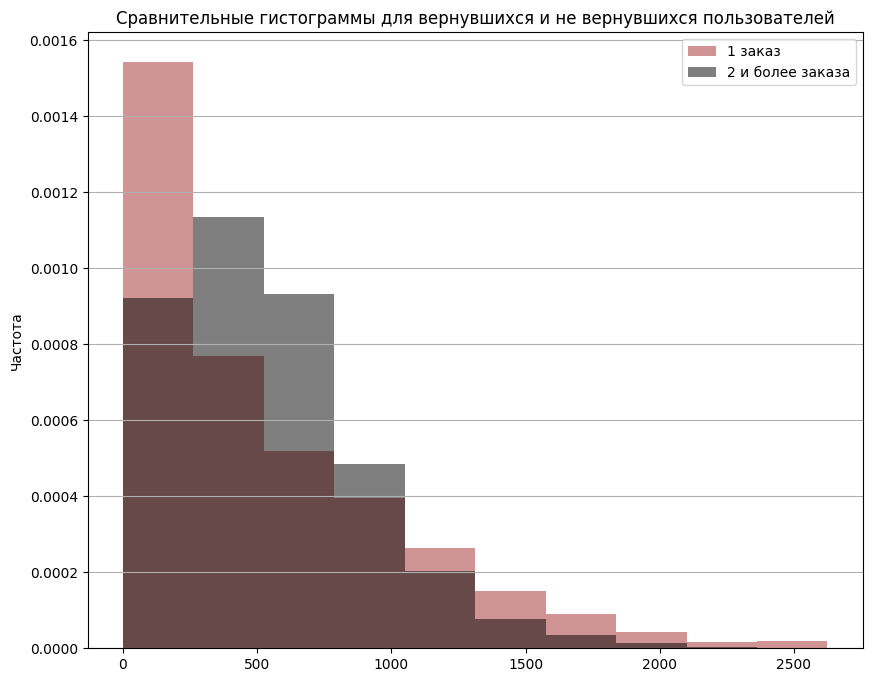

In [84]:
one_order = user_profile[user_profile['is_two'] == False]['mean_revenue']
two_more_order = user_profile[user_profile['is_two'] == True]['mean_revenue']

plt.figure(figsize=(10, 8))
one_order.plot(kind='hist', density=True, color='brown', alpha=0.5, label='1 заказ', bins=10)
two_more_order.plot(kind='hist', density=True, color='black', alpha=0.5, label='2 и более заказа', bins=10)
plt.grid(axis='y')
plt.ylabel("Частота")
plt.title("Сравнительные гистограммы для вернувшихся и не вернувшихся пользователей")
plt.legend()

Пользователи первой группы, совершившие 1 заказ, концентрируются больше всего в пределах 250 рублей. Пользователи второй группы, вернувшиеся повторно, концентрируются больше всего в пределах от 250 рублей до 750.

В целом в каждой группе с увеличением средней выручки уменьшается частота появления таких значений, не беря в учет промежуток гистограммы в пределах 250 для пользователей, совершивших 2 и более заказа. Различие между группами заключается в том, что в группе вернувшихся пользователей значения скоцентрированы возле более высоких значений.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


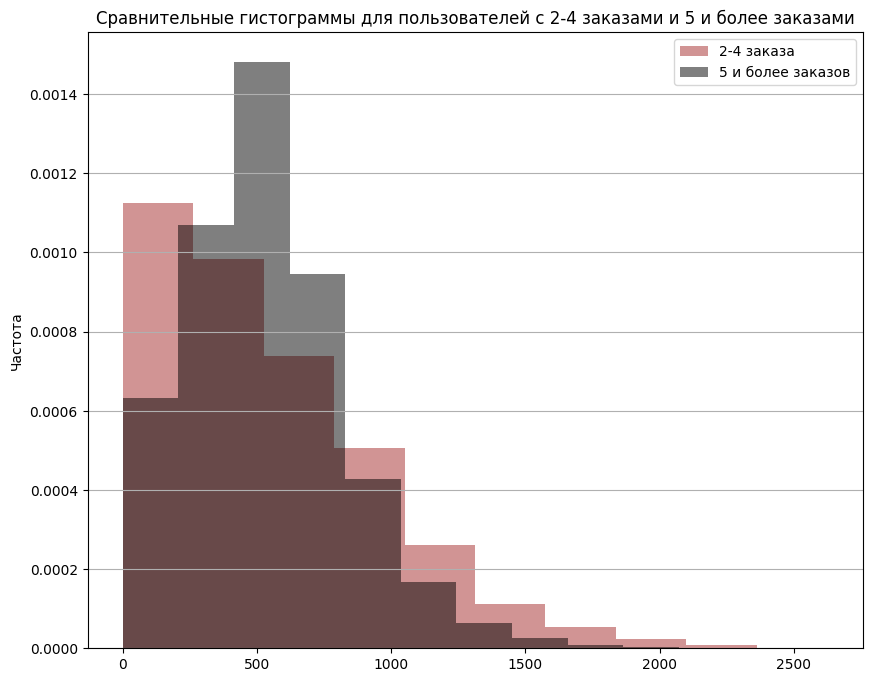

In [85]:
two_four_orders = user_profile[(user_profile['is_two'] == True) & (user_profile['is_five'] == False)]['mean_revenue']
five_more_order = user_profile[user_profile['is_five'] == True]['mean_revenue']

plt.figure(figsize=(10, 8))
two_four_orders.plot(kind='hist', density=True, color='brown', alpha=0.5, label='2-4 заказа', bins=10)
five_more_order.plot(kind='hist', density=True, color='black', alpha=0.5, label='5 и более заказов', bins=10)
plt.grid(axis='y')
plt.ylabel("Частота")
plt.title("Сравнительные гистограммы для пользователей с 2-4 заказами и 5 и более заказами")
plt.legend()

Между группами с 2-4 заказами и 5 и более заказами есть разница в том, что пользователи с 5 и более заказами сконцентрированы возле более высоких значений от 240 до 770, с 2-4 заказами возле значений в пределах 250-500.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Изучим распределение пользователей по среднему кол-ву билетов в заказе (mean_tickets_count).

Text(0.5, 0, 'Среднее количество билетов')

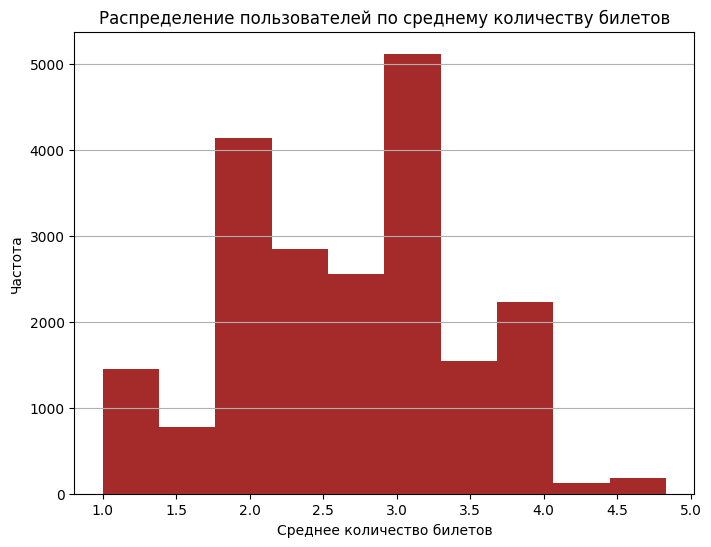

In [86]:
user_profile['mean_tickets_count'].plot(kind='hist', figsize=(8, 6), title='Распределение пользователей по среднему количеству билетов', color='brown', bins=10).grid(axis='y')
plt.ylabel('Частота')
plt.xlabel('Среднее количество билетов')

Чаще всего люди покупают по 3 и 2 билета за заказ, наименее популярны для покупки 1 и 4 билета.

Разделим пользователей на сегменты по среднему количеству билетов в заказе. Для удобства создадим серию с наименованием групп в порядке, как они идут в профиле пользователей, и с указанием, была ли совершена покупка билетов повторно.

In [87]:
def create_segments(row):
    if 1 <= row['mean_tickets_count'] < 2:
        return '1-2 tickets'
    elif 2 <= row['mean_tickets_count'] < 3:
        return '2-3 tickets'
    elif 3 <= row['mean_tickets_count'] < 5:
        return '3-5 tickets'
    elif row['mean_tickets_count'] >= 5:
        return '5 and more tickets'

count_tickets_segments = pd.DataFrame(user_profile.apply(create_segments, axis=1))
count_tickets_segments = count_tickets_segments.join(user_profile['is_two'], how='inner')
count_tickets_segments.columns = ['segment', 'is_two']
count_tickets_segments.head()

,segment,is_two
0,3-5 tickets,False
1,3-5 tickets,True
2,2-3 tickets,True
3,3-5 tickets,False
4,1-2 tickets,True


Для каждого сегмента посчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [88]:
orders_segment = count_tickets_segments.groupby(by=['segment'])['is_two'].agg(['sum', 'count']) 
orders_segment['Доля вернувшихся пользователей'] = orders_segment['sum'] / orders_segment['count']
orders_segment = orders_segment.sort_values(by='segment')
orders_segment = orders_segment.rename(columns={'count': 'Общее число пользователей'})
orders_segment[['Общее число пользователей', 'Доля вернувшихся пользователей']]

,Общее число пользователей,Доля вернувшихся пользователей
segment,,
1-2 tickets,2412,0.512852
2-3 tickets,9483,0.735421
3-5 tickets,9059,0.542996


При анализа следует учесть, что ранее были отфильтрованы заказы со средним количеством билетов, равным 5 и более. 

Пользователи распределены примерно одинаково по сегментам с 2-3 билетами и 3-5 (около 9100-9500 человек). В сегменте 1-2 видна большая разница по сравнению с ними: всего 2400 человек.

Доли вернувшихся пользователей для 1-2 билетов и 3-5 билетов равны примерно 0.52, 2-3 билетов - около 0.74. 

#### Промежуточный вывод


В результате выполнения задания 4.2 были построены сравнительные гистограммы распределения средней выручки для вернувшихся и не вернувшихся пользователей (оказалось, что выручка с заказов вернувшихся пользователей более высокая), гистограммы распределения средней выручки для пользователей с 2-4 заказами и 5 и более заказами (оказалось, что выручка с заказов людей с 5 и более покупками более высокая).

Было изучено распределение пользователей по среднему количеству билетов в заказе. Выяснилось, что чаще всего люди покупают в среднем по 2-3 билета, меньше всего - 1 и 4+ билетов. Пользователи оказались распределены примерно одинаково по сегментам с 2-3 билетами и 3-5 (около 9100-9500 человек). В сегменте 1-2 видна большая разница по сравнению с ними: всего 2400 человек. Доли вернувшихся пользователей для 1-2 билетов и 3-5 билетов составили примерно 0.52, 2-3 билетов - около 0.74.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="4.3-bullet"></a>
#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Выделим из дат первого заказа день недели. 

In [89]:
grouped_day = pd.DataFrame(user_profile['first_order_dt'].dt.day_name()) 
grouped_day = grouped_day.join(user_profile['is_two'], how='inner')
grouped_day = grouped_day.rename(columns={'first_order_dt': 'day_of_week'})
grouped_day.head()

,day_of_week,is_two
0,Tuesday,False
1,Tuesday,True
2,Saturday,True
3,Thursday,False
4,Sunday,True


Для каждого дня недели посчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [90]:
day_of_week = grouped_day.groupby(by='day_of_week')['is_two'].agg(['count', 'sum'])
day_of_week['Доля вернувшихся пользователей'] = day_of_week['sum'] / day_of_week['count']
day_of_week = day_of_week.rename(columns={'count': 'Общее число пользователей'})
day_of_week = day_of_week.drop(columns='sum')
day_of_week

,Общее число пользователей,Доля вернувшихся пользователей
day_of_week,,
Friday,3150,0.612698
Monday,2847,0.639972
Saturday,3217,0.643146
Sunday,2692,0.615156
Thursday,3022,0.605559
Tuesday,3056,0.631872
Wednesday,2970,0.637037


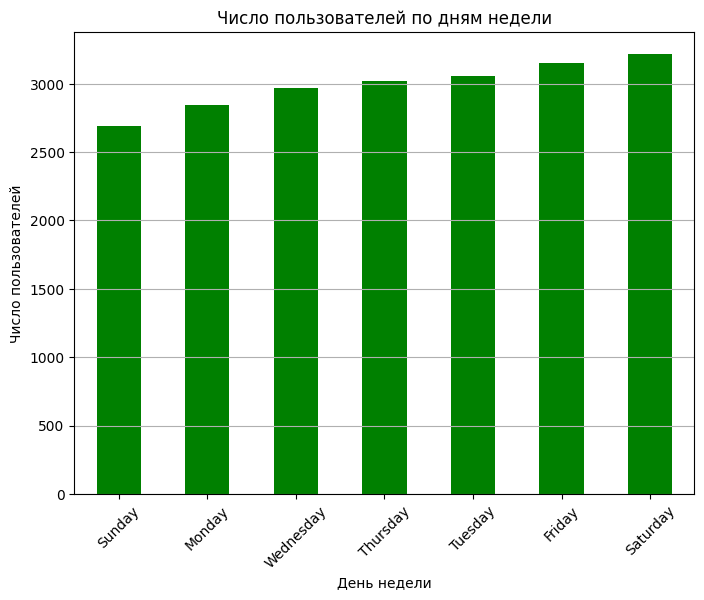

In [91]:
day_of_week = day_of_week.sort_values(by='Общее число пользователей')
day_of_week.plot(kind='bar', y='Общее число пользователей', figsize=(8, 6), legend=False, color='green', rot=45, xlabel='День недели', ylabel='Число пользователей', title='Число пользователей по дням недели').grid(axis='y')

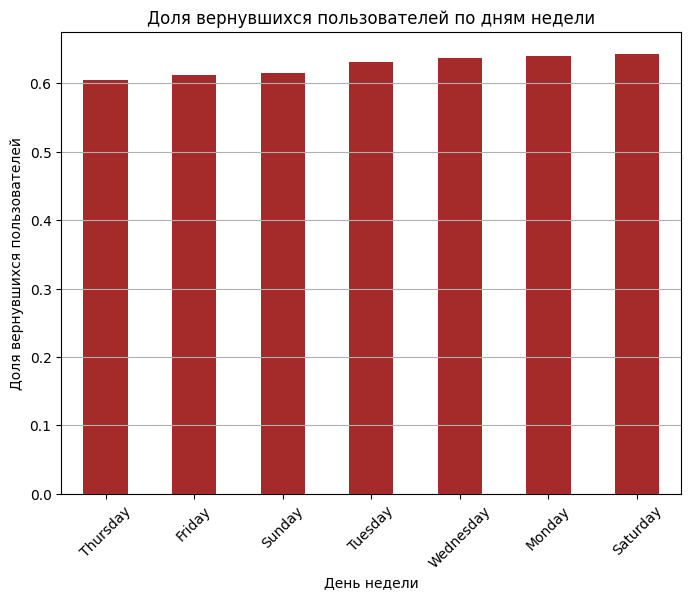

In [92]:
day_of_week = day_of_week.sort_values(by='Доля вернувшихся пользователей')
day_of_week.plot(kind='bar', y='Доля вернувшихся пользователей', figsize=(8, 6), legend=False, color='brown', rot=45, xlabel='День недели', ylabel='Доля вернувшихся пользователей', title='Доля вернувшихся пользователей по дням недели').grid(axis='y')

Число пользователей по дням недели варьируется от 2800 до 3200 человек. Доля вернувшихся - от 0,6 до 0,64. Можно предположить, что день недели, в который совершена первая покупка, почти не оказывает влияние на вероятность возврата клиента. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Рассчитаем среднее время между заказами.

In [93]:
two_four_orders = user_profile[(user_profile['is_two'] == True) & (user_profile['is_five'] == False)]['mean_days_since_prev'].mean()
five_more_order = user_profile[user_profile['is_five'] == True]['mean_days_since_prev'].mean()

print(f'2-4 заказа: {two_four_orders};\n5 и больше заказов: {five_more_order}')

2-4 заказа: 21.543046951293945;
5 и больше заказов: 9.934139251708984


Таким образом, чем меньше временной интервал, тем большее количество покупок совершают пользователи. Вероятно, пользователи, которые совершают большее количество заказов, сильнее интересуются различными мероприятиями, посещают их, а поэтому и чаще покупают билеты.

#### Промежуточный вывод

В результате выполнения задания 4.3 был выделен день недели из даты первого заказа, для каждого дня недели посчитано общее число пользователей и доля вернувшихся пользователей, построены графики. Было сделано предположение, что день недели, в который совершена первая покупка, почти не оказывает влияние на вероятность возврата клиента.

Было рассчитано среднее время между заказами для двух групп пользователей:
- совершивших 2–4 заказа;
- совершивших 5 и более заказов.

Сделан вывод, что пользователи, совершающие больше заказов, имеют меньшие временные промежутки между ними.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="4.4-bullet"></a>
#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [94]:
user_profile.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'device_first_order',
       'region_first_order', 'service_name_first_order', 'first_event',
       'total_orders', 'mean_revenue', 'mean_tickets_count',
       'mean_days_since_prev', 'is_two', 'is_five'],
      dtype='str')

In [95]:
correlation_matrix = user_profile[['total_orders', 'first_order_dt', 'last_order_dt', 'device_first_order',
       'region_first_order', 'service_name_first_order', 'first_event', 'mean_revenue', 'mean_tickets_count',
       'mean_days_since_prev', 'is_two', 'is_five']].phik_matrix(interval_cols=['total_orders', 'mean_revenue', 'mean_tickets_count', 'mean_days_since_prev'])
correlation = pd.DataFrame(correlation_matrix['total_orders'][1:]).sort_values(by='total_orders')
correlation

,total_orders
device_first_order,0.027961
first_event,0.029935
service_name_first_order,0.032876
region_first_order,0.124383
mean_revenue,0.223327
mean_days_since_prev,0.299262
is_two,0.317538
mean_tickets_count,0.384992
last_order_dt,0.416118
first_order_dt,0.430257


Text(0.5, 58.5815972222222, 'Число заказов')

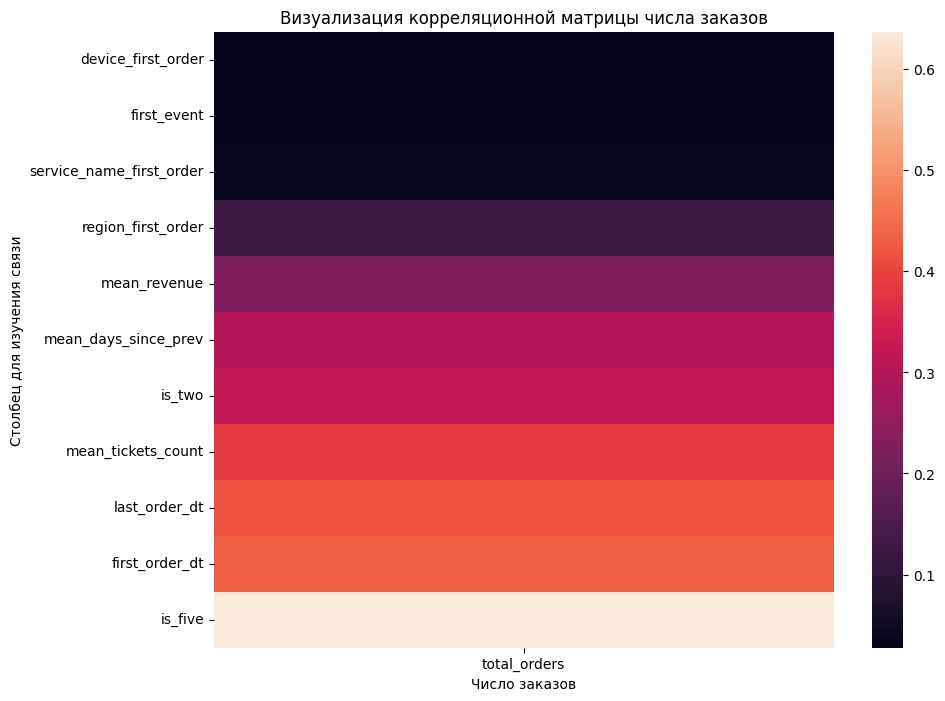

In [96]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation)
plt.title('Визуализация корреляционной матрицы числа заказов')
plt.ylabel('Столбец для изучения связи')
plt.xlabel('Число заказов')

Умеренная положительная корреляция существует между числом заказов и:
- фактом совершения пользователем 5 и более заказов;
- датой первого заказа;
- датой последнего заказа;
- средним количество билетов в заказе.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="5-bullet"></a>
### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

---

#### Информация о данных.

Работа проходила с измененными данными датасета Яндекс Афиши, содержащими информацию о покупках пользователей на сервисе. Цель проекта заключалась в анализе лояльности пользователей с целью лучшего понимания их поведения.

Первоначально работа проходила с датафреймом df, объем которого был 290611 строк и 14 столбцов. Перед обработкой данных для приведения выручки с заказов к единой валюте был использован датасет final_tickets_tenge_df, содержащий информацию о курсе рубля для 100 тенге. Для него было посчитано количество рублей в 1 тенге, после чего эти данные использовались в основном датасете для конвертации. 

При предобработке датасета данные с пропусками были оставлены в исходном виде, были уменьшены размерности типов данных столбцов `order_id`, `revenue`, `tickets_count`, `days_since_prev`, `event_id`, нормализация категориальных данных не потребовалась, столбцы `revenue_rub`, `tickets_count` были очищены от выбросов.

Для анализа был создан профиль пользователя, содержащий для каждого пользователя данные о первом заказе, дате последнего заказа, общем количестве заказов, средней выручке, количестве билетов, времени между заказами, а также бинарные столбцы с информацией о том, было ли совершено пользователем 2 или 5 и более заказов. Его столбцы `total_orders` и `mean_tickets_count` были отфильтрованы по 99-му перцентилю.


#### Основные результаты анализа.
При анализе использовался профиль пользователей, состоящий из 20954 строк. Средняя выручка с одного заказа составляет 535 рублей, 63% пользователей совершают заказы повторно, 37% пользователей совершили лишь одну покупку. 

При анализе было выяснено, что распределение пользователей как по типу мероприятия, так и по типу устройства, регионам и билетному оператору неравномерное. На возврат пользователей могут оказывать влияение тип первого посещенного мероприятия, выбранный мобильный оператор. Чаще всего люди покупают по 2-3 билета, причем процент возвратов для людей, покупающих такое количество билетов, так же наибольший - около 74%. Выяснилось, что выручка с заказов возвращающихся пользователей более высокая. День недели почти не оказывает влияние на возврат пользователей, в то время как интервалы между покупками могут иметь значение - чем меньше интервалы, тем чаще и больше покупок совершает пользователь. Кроме того, согласно результатам корреляционного анализа, с числом покупок могут быть связаны факт совершения 5 и более заказов, дата первого и последнего заказов, среднее количество билетов в заказе.

Так, в число перспективных клиентов могут попасть люди, который покупают в среднем по 2-3 билета на определенные типы мероприятий (например, на концерты), причем делают это чаще, чем другие пользователи. Точную настройку рекламы можно проводить на аудиторию, совершающую покупки более часто и на более большие суммы, нежели другие пользователи. В дополнительных маркетинговых усилиях нуждаются пользователи, которые посещают только менее популярные типы мероприятий, делают это редко.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/AnnaTN/Project_Yandex_afisha_course.git